# Fixed-axis Rotation
{sub-ref}`today` | {sub-ref}`wordcount-words` words | {sub-ref}`wordcount-minutes` min read

## Rotational Variables

### Angular Velocity

Uniform circular motion is motion along a circle at constant speed (see [Section 4.3](https://saturnaxis.github.io/IntroPhysics/Chapter04/motion-in-2D-3D.html#uniform-and-nonuniform-circular-motion)).  It is the simplest case of rotational motion and is helpful when introducing rotational variables.

`````{tab-set}
````{tab-item} OpenStax figure
```{figure-md} particle-circle-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/618aee1d04f50ff7949d3f786050c2d7f1260371" alt="particle moving in a circle"  style="max-width:70%; height:auto;">

OpenStax diagram of a particle moving on a circle with radial vector $\vec{r}$ and angle $\theta$.
```
````
````{tab-item} Sweeping vector
```{glue:figure} circle_gif
:name: "fig-circle-animation"


Animation of the same motion; the path is light gray, and the particle and trail are colored.
```
````
`````

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os
from myst_nb import glue

# ----------------------------
# Parameters you can tweak
# ----------------------------
R = 1.0                  # circle radius
omega = 1.0              # angular speed (rad/s) for parameterization
n_frames = 240           # total frames in the animation
trail = True             # show a colored trail behind the particle
trail_len = 60           # how many previous points to keep in the trail
particle_color = "crimson"
path_color = "0.75"      # light gray (0=black, 1=white)
vector_color = "k"

# ----------------------------
# Set up the figure/axes
# ----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.25*R, 1.25*R)
ax.set_ylim(-1.25*R, 1.25*R)

# Axes lines (like your figure)
ax.axhline(0, color="k", lw=1)
ax.axvline(0, color="k", lw=1)

# Remove ticks for a cleaner "textbook figure" look
ax.set_xticks([])
ax.set_yticks([])

# ----------------------------
# Precompute the circle path
# ----------------------------
theta = np.linspace(0, 2*np.pi, 400)
x_path = R*np.cos(theta)
y_path = R*np.sin(theta)

# Fixed path in light gray
ax.plot(x_path, y_path, color=path_color, lw=3, zorder=1)

# Animated artists: vector, particle, and optional trail
vec_line, = ax.plot([], [], color=vector_color, lw=3, zorder=3)
pt, = ax.plot([], [], "o", ms=8, color=particle_color, zorder=4)
trail_line, = ax.plot([], [], color=particle_color, lw=3, alpha=0.9, zorder=2)

# ----------------------------
# Animation functions
# ----------------------------
def init():
    vec_line.set_data([], [])
    pt.set_data([], [])
    trail_line.set_data([], [])
    return vec_line, pt, trail_line

def update(i):
    # Angle for this frame (wraps naturally)
    th = 2*np.pi * i/(n_frames-1)

    x = R*np.cos(th)
    y = R*np.sin(th)

    # Vector from origin to particle
    vec_line.set_data([0, x], [0, y])

    # Particle
    pt.set_data([x], [y])

    # Trail (colored arc behind the particle)
    if trail:
        i0 = max(0, i - trail_len)
        th_tr = 2*np.pi * np.arange(i0, i+1)/(n_frames-1)
        trail_line.set_data(R*np.cos(th_tr), R*np.sin(th_tr))
    else:
        trail_line.set_data([], [])

    return vec_line, pt, trail_line

anim = FuncAnimation(fig, update, frames=n_frames, init_func=init,interval=30, blit=True)
plt.close(fig)

# Glue relative path for MyST
glue("circle_gif", HTML(anim.to_jshtml()),display=False)

'circular_motion.gif'

In Figures {numref}`{number}<particle-circle-fig>` and {numref}`{number}<fig-circle-animation>`, we show a particle moving in a circle.  The coordinate system is fixed and serves as a frame of reference to define the particle's position.  Its position vector $\vec{r}$ sweeps out the angle $\theta$ in a counterclockwise direction.

The angular position $\theta$ describes how far the position vector has rotated in the $x$-$y$ plane.  As the particle moves in its circular path, it also traces an arc length $s$.  The particle may complete more than one revolution around the circle.  This means that the angle $\theta$ may be greater than $2\pi$, and the arc length $s$ can be greater than the circumference, $2\pi r$. 

The angle is related to the radius of the circle and the arc length by

\begin{align}
\theta &= \frac{s}{r}, \\
s &= r\theta.
\end{align}

The angle $\theta$ has units of radians (rad), where there are $2\pi$ radians in $360^\circ$.

```{note}
The radian measure is a ratio of length measurements, and therefore is a dimensionless quantity.
```

As the particle moves along its circular path, its angular position changes and it undergoes an angular displacement over $\Delta \theta$.

We can assign a vector $\vec{\theta}$, which represents a vector `out-of-the-page` in Fig. {numref}`{number}<particle-circle-fig>`.  The angular position vector $\vec{r}$ and the arc length $\vec{s}$ both lie in the plane of the page.  These three vectors are related to each other by a cross-product, or

\begin{align} 
\vec{s} = \vec{\theta} \times \vec{r}.
\end{align}

```{figure-md} theta-cross-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/f4e805e269e812606739587d2cc1f2f5fe74c80a" alt="theta cross product"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

The magnitude of the **angular velocity** $\omega$ is the time rate of change of the angle $\theta$ as the particle moves in its circular path.  The *instantaneous angular velocity* is defined using the limit definition when $\Delta t\rightarrow 0$ in the average velocity, or

\begin{align}
\omega_{\rm ave} &= \frac{\Delta \theta}{\Delta t}, \\[6pt]
\omega &= \lim_{\Delta t \rightarrow 0}\frac{\Delta \theta}{\Delta t} = \frac{d\theta}{dt}.
\end{align}

The units of angular velocity are *radians per second* (or ${\rm rad/s}$), where angular velocity is also referred to as the rotation rate.

```{warning}
Often, we are given the rotation rate in *revolutions* or *cycles* per second.  To find the angular velocity, we must multiply by $2\pi$ (i.e., the number of radians in a revolution or cycle).
```

Since the direction fo a positive angle in a circle is counterclockwise, we take counterclockwise as positive for the angular velocity as well.

The angular velocity is related to the tangential speed ($v_t = ds/dt$) of a particle by differentiation with respect to time.  This can be shown by

\begin{align*}
s&=r\theta,\\
\frac{ds}{dt} &= \frac{d}{dt}\left(r\theta\right), \\
&= \frac{dr}{dt}\theta + r\frac{d\theta}{dt}.
\end{align*}

Since $r$ represents the radius and is a constant, the factor $\frac{dr}{dt} = 0$.  By substitution of the instantaneous angular velocity $\omega$, we arrive at

\begin{align}
\frac{ds}{dt} &= r\frac{d\theta}{dt},\\[6pt]
v_t &= r\omega.
\end{align}

The tangential speed $v_t$ increases with its distance from the axis of rotation for a constant angular velocity (see Fig. {numref}`{number}<tangent-velocity-fig>`).  Two particles are placed at different radii on a rotating disk with a constant angular velocity $\omega$.  As the disk rotates, $v_t$ increases linearly with the radius from the axis of rotation.

```{figure-md} tangent-velocity-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/4ef633382c4f545475a0041f897919b1d78e6a9f" alt="tangent velocity example"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

From Fig. {numref}`{number}<tangent-velocity-fig>`, we see that

\begin{align*}
v_1 &= r_1 \omega_1, \\
v_2 &= r_2 \omega_2.
\end{align*}

But the disk has a constant angular velocity ($\omega_1=\omega_2=\omega$).  This means that we can solve for $\omega$ in both expressions and set them equal to each other:

\begin{align*}
\frac{v_1}{r_1} &= \frac{v_2}{r_2}, \\
v_1 &= \left(\frac{r_1}{r_2}\right)v_2, \\
v_2 &= \left(\frac{r_2}{r_1}\right)v_1.
\end{align*}

Since, $r_2 > r_1$, we can see that $v_2 > v_1$.

In [21]:
import numpy as np
import plotly.graph_objects as go
from pathlib import Path
import plotly.io as pio
pio.renderers.default = "iframe"

outdir = Path("../_static/plotly")
outdir.mkdir(parents=True, exist_ok=True)
# ============================================================
# 3D Right-Hand-Rule / Angular Velocity Diagram (Plotly)
# Upgrades included:
#   (1) subtle radial gradient disk in the x–y plane
#   (2) circular direction arrows on the rim (CCW)
#   (3) fixed default camera for the classic 3-axis corner view
# ============================================================
# -----------------------------
# Parameters (edit as needed)
# -----------------------------
R = 1.0                 # disk radius
L = 1.45                # axis half-length
omega_len = 1.25        # omega vector length
disk_opacity = 0.35
disk_n_r = 70
disk_n_theta = 160
# Rim arrow styling
n_rim_arrows = 4        # number of arrows around the rim
rim_arrow_len = 0.22    # arrow size (in data units)
rim_arrow_spread_deg = 25
# -----------------------------
# Disk mesh in x–y plane (with radial gradient)
# -----------------------------
r = np.linspace(0, R, disk_n_r)
th = np.linspace(0, 2*np.pi, disk_n_theta)
rr, tt = np.meshgrid(r, th)
X = rr * np.cos(tt)
Y = rr * np.sin(tt)
Z = np.zeros_like(X)
# Radial gradient control (0 at center → 1 at rim)
C = rr / R
# -----------------------------
# Rim circle boundary
# -----------------------------
th_c = np.linspace(0, 2*np.pi, 500)
xc = R*np.cos(th_c)
yc = R*np.sin(th_c)
zc = np.zeros_like(th_c)
# -----------------------------
# Rim direction arrows (CCW)
# -----------------------------
def rot2(u, v, angle):
    ca, sa = np.cos(angle), np.sin(angle)
    return ca*u - sa*v, sa*u + ca*v
phi = np.deg2rad(rim_arrow_spread_deg)
# Choose arrow anchor angles (avoid clutter with axes)
arrow_angles = np.linspace(0.25*np.pi, 2*np.pi + 0.25*np.pi, n_rim_arrows, endpoint=False)
arrow_segments = []  # list of 2-segment "V" arrowheads
for a in arrow_angles:
    # point on rim
    x0, y0 = R*np.cos(a), R*np.sin(a)
    # CCW tangent direction at angle a is (-sin a, cos a)
    tx, ty = -np.sin(a), np.cos(a)
    # two legs of arrowhead (V shape), pointing "backward" from the head point
    u1x, u1y = rot2(tx, ty, +phi)
    u2x, u2y = rot2(tx, ty, -phi)
    seg1 = np.array([[x0, y0, 0.0],[x0 - rim_arrow_len*u1x, y0 - rim_arrow_len*u1y, 0.0]])
    seg2 = np.array([[x0, y0, 0.0],[x0 - rim_arrow_len*u2x, y0 - rim_arrow_len*u2y, 0.0]])
    arrow_segments.append(seg1)
    arrow_segments.append(seg2)
# -----------------------------
# Build figure
# -----------------------------
fig = go.Figure()
# (1) Disk with subtle radial gradient
# Use a fixed light-blue colorscale and let surfacecolor (C) drive a gentle gradient.
fig.add_trace(go.Surface(x=X, y=Y, z=Z,surfacecolor=C,colorscale=[[0.0, "rgb(235,240,255)"], [1.0, "rgb(180,195,235)"]],
    cmin=0, cmax=1, showscale=False, opacity=disk_opacity, hoverinfo="skip"))
# Clean boundary edge on the disk
fig.add_trace(go.Scatter3d(x=xc, y=yc, z=zc, mode="lines", line=dict(width=5, color="rgba(80,80,80,0.65)"), showlegend=False, hoverinfo="skip"))
# (2) CCW direction arrows on the rim
for seg in arrow_segments:
    fig.add_trace(go.Scatter3d(x=seg[:, 0], y=seg[:, 1], z=seg[:, 2], mode="lines", line=dict(width=5, color="rgba(80,80,80,0.65)"),
        showlegend=False, hoverinfo="skip"))
# Axes as simple lines (x, y, z)
axis_line = dict(width=5, color="rgba(0,0,0,0.7)")
fig.add_trace(go.Scatter3d(x=[-L, L], y=[0, 0], z=[0, 0], mode="lines", line=axis_line, showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[-L, L], z=[0, 0], mode="lines", line=axis_line, showlegend=False, hoverinfo="skip"))
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[-L, L], mode="lines", line=axis_line, showlegend=False, hoverinfo="skip"))
# Angular velocity vector (green cone) + shaft line
fig.add_trace(go.Scatter3d(x=[0, 0], y=[0, 0], z=[0, omega_len],mode="lines",line=dict(width=7, color="rgba(0,120,0,0.95)"),showlegend=False,hoverinfo="skip"))
fig.add_trace(go.Cone(x=[0], y=[0], z=[omega_len*0.88],u=[0], v=[0], w=[omega_len*0.12],anchor="tail",sizemode="absolute",
    sizeref=0.35,colorscale=[[0, "rgb(0,140,0)"], [1, "rgb(0,140,0)"]],showscale=False,hoverinfo="skip"))
# Label for omega (as 3D text)
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[omega_len*1.05],mode="text",text="𝝎",textfont=dict(size=24),textposition="top center",showlegend=False,hoverinfo="skip"))
# Optional label for rotation sense
fig.add_trace(go.Scatter3d(x=[R*1.05], y=[0], z=[0],mode="text",text=["CCW rotation"],textposition="middle right",showlegend=False,hoverinfo="skip"))
# (3) Fixed default camera (classic 3-axis corner view)
camera = dict(eye=dict(x=1.65, y=1.25, z=0.95),up=dict(x=0, y=0, z=1),center=dict(x=0, y=0, z=0))
# Layout: clean, textbook-like
fig.update_layout(
    scene=dict(
        xaxis=dict(title="x", range=[-L, L], showticklabels=False,showbackground=False, zeroline=False, showgrid=False, ticks=""),
        yaxis=dict(title="y", range=[-L, L], showticklabels=False,showbackground=False, zeroline=False, showgrid=False, ticks=""),
        zaxis=dict(title="z", range=[-L, L], showticklabels=False,showbackground=False, zeroline=False, showgrid=False, ticks=""),
        aspectmode="cube",
        camera=camera), margin=dict(l=0, r=0, t=0, b=0))
fig.update_layout(width=600,height=600,margin=dict(l=0, r=0, t=0, b=0))
fig.write_html(outdir / "omega_3d.html", include_plotlyjs="cdn", full_html=True)
fig.show()

<iframe src="../_static/plotly/omega_3d.html" width="700" height="700" style="border:0;"></iframe>


```{note}
The magnitude of the angular velocity is given by $\omega = d\theta/dt$, which is a scalar.  The vector $\vec{\omega}$ is has a magnitude $\omega$ and points along the axis of rotation.  The direction of rotation ("-" clockwise or "+" counterclockwise) gives the directional information and can be determined via the right-hand rule.
```

One can state a cross product relation to the vector of the tangential velocity $v_t$, which is given by

\begin{align}
\vec{\rm v} = \vec{\omega} \times \vec{r}.
\end{align}

The tangential velocity is the cross product of the angular velocity and the position vector.  In Figure {numref}`{number}<tangent-vel-vector-fig>`a, we see that the angular velocity is in the $+z$-direction, and the rotation in the rotation in the $xy$-plane is counterclockwise.  In Figure {numref}`{number}<tangent-vel-vector-fig>`b, th angular velocity is in the $-z$-direction, giving a clockwise rotation in the $xy$-plane.

```{figure-md} tangent-vel-vector-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/dab97fdf060a41501b0e9fde084bee55b8c7b67d" alt="tangent velocity vector"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

#### **Example Problem**: Rotation of a Flywheel

````{exercise}
:class: etamu-exercise

**The Problem**

> A flywheel rotates such that it sweeps out an angle at the rate of  $\theta = \omega t = (45\ {\rm rad/s})t$ radians. The wheel rotates counterclockwise when viewed in the plane of the page.
>
> (a) What is the angular velocity of the flywheel?  
> (b) What direction is the angular velocity?  
> (c) How many radians does the flywheel rotate through in $30\ {\rm s}$?  
> (d) What is the tangential speed of a point on the flywheel $10\ {\rm cm}$ from the axis of rotation?

---

**The Model**

The angular position of the flywheel is given as a function of time by $\theta(t)=\omega t$. This functional form corresponds to uniform rotational motion because the angular velocity is constant.

The angular velocity is obtained by differentiating the angular position with respect to time. The direction of the angular velocity vector is determined using the right-hand rule. The angular displacement over a time interval is obtained from the change in angular position. The tangential speed of a point located a distance $r$ from the axis of rotation is related to the angular velocity by $v_t = r\omega$.

---

**The Math**

The angular velocity of a rotating object is defined as the time derivative of the angular position,

\begin{align*}
\omega = \frac{d\theta}{dt}.
\end{align*}

**(a)** The angular position of the flywheel is given by $\theta(t) = (45\ {\rm rad/s})t$. Taking the derivative of this expression with respect to time gives

\begin{align*}
\omega = 45\ {\rm rad/s}.
\end{align*}

**(b)** The direction of the angular velocity follows from the right-hand rule. Curling the fingers of the right hand in the direction of rotation, which is counterclockwise in the plane of the page, causes the thumb to point outward from the page. Therefore, the angular velocity vector points out of the page.

**(c)** The angular displacement during a time interval is the change in angular position,

\begin{align*}
\Delta\theta = \theta(t)-\theta(0).
\end{align*}

Substituting the expression for $\theta(t)$ into this equation gives

\begin{align*}
\Delta\theta &= (45\ {\rm rad/s})(30\ {\rm s}) \\
&= 1350\ {\rm rad}.
\end{align*}

**(d)** The tangential speed of a point located a distance $r$ from the axis of rotation is

\begin{align*}
v_t = r\omega.
\end{align*}

The point is located $10\ {\rm cm}$ from the axis of rotation, which corresponds to $r=0.10\ {\rm m}$. Substituting the values gives

\begin{align*}
v_t &= (0.10\ {\rm m})(45\ {\rm rad/s}) \\
&= 4.5\ {\rm m/s}.
\end{align*}

---

**The Conclusion**

The flywheel rotates with a constant angular velocity of $45\ {\rm rad/s}$, and the angular velocity vector points out of the page according to the right-hand rule. During a time interval of $30\ {\rm s}$, the flywheel rotates through an angular displacement of $1.35\times10^{3}\ {\rm rad}$. A point located $10\ {\rm cm}$ from the axis of rotation moves with a tangential speed of $4.5\ {\rm m/s}$.  This result shows that even moderate angular velocities can produce large angular displacements when the motion continues over long time intervals. 

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same physical relationships used in the derivation. The script computes the angular displacement using the rotational kinematic relation and calculates the tangential speed from the linear–rotational relationship.  Because the computation implements the same equations derived analytically, the numerical results reproduce the analytical solution, providing an independent confirmation of the calculations.

```python
import numpy as np


omega = 45 # Angular velocity (rad/s)
t = 30 # Time interval (s)
r = 0.10 # Distance from axis (m)

# Angular displacement
delta_theta = omega * t
# Tangential speed
v_t = r * omega

print(f"The angular displacement after 30 s is {delta_theta:.0f} radians.")
print(f"The tangential speed at r = 0.10 m is {v_t:.1f} m/s.")
```
````

### Angular Acceleration

Although uniform circular motion can be used in many situations, not all motion is uniform.  For example, an ice skater can increase her angular speed, by pulling in her arms.  As a result, we need to define an **angular acceleration** for describing situations where $\omega$ changes.

The faster the change in $\omega$, the greater the acceleration. We define the **instantaneous angular acceleration** $\alpha$ as the derivative of angular velocity with respect to time:

\begin{align}
\alpha &= \lim_{\Delta t \rightarrow 0} \frac{\Delta w}{\Delta t},\\ 
&= \frac{d\omega}{dt} = \frac{d^2\theta}{dt^2}.
\end{align}

The above definition takes the limit of the average angular acceleration ($\bar{\omega} = \frac{\Delta \omega}{dt}$) as $\Delta t \rightarrow 0$.  The units of angular acceleration are ${\rm rad/s^2}$.

In the same way as we defined the angular velocity vector $\vec{\omega}$, we can define a vector associated with the angular acceleration $\vec{\alpha}$.  If the angular velocity is along the positive $z$-axis and 

- $\frac{d\omega}{dt}>0$, then the angular acceleration ${\alpha}>0$ and points along the $+z$-axis.
- $\frac{d\omega}{dt}<0$, then the angular acceleration is negative and points along the $-z$-axis. 

```{figure-md} rotation-accel-vector-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/ead13a566820d6286089d85134c03bbf86bfc0aa" alt="rotation acceleration vector"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

TWe can express the tangential acceleration vector as a cross product of the angular acceleration and the position vector.  This expression can be found using the [properties of cross products](https://en.wikipedia.org/wiki/Cross_product#Differentiation):

\begin{align}
\vec{a} &= \frac{d\vec{\rm v}}{dt}, \\
&= \frac{d}{dt}\left(\vec{\omega} \times \vec{r}\right), \\
&= \frac{d\vec{\omega}}{dt}\times \vec{r} + \vec{\omega}\times \frac{d\vec{r}}{dt}, \\
&= \vec{\alpha} \times \vec{r}.
\end{align}

```{admonition} Vector Triple Product
:class: note, dropdown
The [vector triple product](https://en.wikipedia.org/wiki/Triple_product#Vector_triple_product) can be written generally using three vectors: $\vec{a},\ \vec{b},\ \text{and}\ \vec{c}$ as

$$ \vec{a} \times \left(\vec{b} \times \vec{c}\right) = -\vec{c} \times \left(\vec{a} \times \vec{b}\right). $$


If $\vec{a} = \vec{b}$, then we have

$$\vec{a} \times \left(\vec{a} \times \vec{c}\right) = -\vec{c} \times \left(\vec{a} \times \vec{a}\right) = \vec{0}. $$
```

The vector relationships for the angular and tangential acceleration are shown in Figure {numref}`{number}<angular-accel-vector>` where $\vec{a}$ and $\vec{r}$ lie in the $xy$-plane and the $\vec{\alpha}$ points perpendicular to the $xy$-plane.

```{figure-md} angular-accel-vector
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260105.231123/resources/ead13a566820d6286089d85134c03bbf86bfc0aa" alt="angular acceleration vector"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

We can relate the tangential acceleration of a point on a rotating body at a distance from the axis of rotation in a similar way that we related the tangential speed to the angular velocity.  We find the tangential acceleration by

\begin{align}
v_t &= r\omega, \\
a_t &= \frac{d(r\omega)}{dt},\\
&= \frac{dr}{dt}\omega + r\frac{d\omega}{dt}, \\
&= r\alpha.
\end{align}

The radius $r$ is constant, which means that $\frac{dr}{dt} = 0$. Then we used the definition of the angular acceleration: $\alpha = d\omega/dt$.

Thus, the tangential acceleration $a_t$ is product of the radius and the angular acceleration.

```{admonition} Problem-Solving Strategy
:class: note

**Rotational Kinematics**  
1. Identify the unknowns, where a sketch of the situation is useful.
2. Identify the knowns by making a complete list inferred from the problem.
3. Solve the appropriate equation for the unknown.  It can be useful to think in terms of the translational analog.
4. Substitute the known values.  Be sure to use units of radians for angles.
5. Check your answer for reasonableness: Does it make sense?
```

#### **Example Problem**: Spinning Bicycle Wheel

````{exercise}
:class: etamu-exercise

**The Problem**

> A bicycle mechanic mounts a bicycle on the repair stand and starts the rear wheel spinning from rest to a final angular velocity of $250\ {\rm rpm}$ in $5.00\ {\rm s}$.
>
> (a) Calculate the average angular acceleration in ${\rm rad/s^2}$.  
> (b) If she now hits the brakes, causing an angular acceleration of $-87.3\ {\rm rad/s^2}$, how long does it take the wheel to stop?

---

**The Model**

The wheel undergoes rotational motion about a fixed axis. The relationship between angular velocity, angular acceleration, and time can be described using the kinematic definitions for rotational motion.  Angular acceleration is defined as the rate of change of angular velocity with respect to time. When the angular acceleration is constant, the change in angular velocity over a time interval can be related directly to the angular acceleration and elapsed time.

These relationships allow us to determine the angular acceleration from the change in angular velocity and the time interval, and to determine the stopping time when a known angular acceleration reduces the angular velocity to zero.

---

**The Math**

**(a)** The average angular acceleration is defined as

\begin{align*}
\bar{\alpha} = \frac{\Delta\omega}{\Delta t}.
\end{align*}

The wheel starts from rest and reaches a final angular velocity of $250\ {\rm rpm}$ in $5.00\ {\rm s}$. The angular velocity must first be converted to radians per second,

\begin{align*}
\omega &= 250\ \frac{\rm rev}{\rm min} \cdot \frac{2\pi\ {\rm rad}}{\rm rev} \cdot \frac{1\ {\rm min}}{60\ {\rm s}} \\
&= 26.2\ {\rm rad/s}.
\end{align*}

Substituting this value into the definition of angular acceleration gives

\begin{align*}
\bar{\alpha} &= \frac{26.2\ {\rm rad/s}}{5.00\ {\rm s}} \\
&= 5.24\ {\rm rad/s^2}.
\end{align*}

**(b)** When the brakes are applied, the angular velocity decreases from $26.2\ {\rm rad/s}$ to zero. The stopping time can therefore be determined from the definition of angular acceleration,

\begin{align*}
\alpha = \frac{\Delta\omega}{\Delta t}.
\end{align*}

Solving this expression for the time interval gives

\begin{align*}
\Delta t = \frac{\Delta\omega}{\alpha}.
\end{align*}

The change in angular velocity is $\Delta\omega = -26.2\ {\rm rad/s}$ and the angular acceleration is $-87.3\ {\rm rad/s^2}$. Substituting these values gives

\begin{align*}
\Delta t &= \frac{-26.2\ {\rm rad/s}}{-87.3\ {\rm rad/s^2}} \\
&= 0.300\ {\rm s}.
\end{align*}

---

**The Conclusion**

The wheel experiences an average angular acceleration of $5.24\ {\rm rad/s^2}$ as it spins up from rest. When the brakes are applied, the wheel stops in $0.300\ {\rm s}$ under an angular acceleration of $-87.3\ {\rm rad/s^2}$.

These results illustrate how a relatively small angular acceleration applied over several seconds can gradually increase the wheel's rotation, whereas a much larger negative acceleration can bring the wheel to rest very quickly.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same relationships used in the derivation. The script converts the angular velocity from revolutions per minute to radians per second, computes the average angular acceleration, and determines the stopping time using the rotational kinematic definitions. Because the computation directly implements the same physical equations used in the derivation, the numerical results reproduce the calculated angular acceleration and stopping time, confirming the correctness of the solution.

```python
import numpy as np

omega_rpm = 250
omega = omega_rpm * 2*np.pi / 60

t = 5.00
alpha_avg = omega / t

alpha_brake = -87.3
t_stop = -omega / alpha_brake

print(f"The angular velocity is {omega:.1f} rad/s.")
print(f"The average angular acceleration is {alpha_avg:.2f} rad/s^2.")
print(f"The stopping time is {t_stop:.3f} s.")
```
````

#### **Example Problem**: Wind Turbine

#### **Example Problem**: Wind Turbine Shut Down

````{exercise}
:class: etamu-exercise

**The Problem**

> A wind turbine that is initially rotating counterclockwise on a wind farm is being shut down for maintenance. It takes $30\ {\rm s}$ for the turbine to go from its operating angular velocity to a complete stop in which the angular velocity function is $\omega(t)=\left[(t\,{\rm s}^{-1}-30)^2/100\right]{\rm rad/s}$, where $t$ is the time in seconds. If the turbine is rotating counterclockwise looking into the page,
>
> (a) what are the directions of the angular velocity and acceleration vectors?  
> (b) What is the average angular acceleration?  
> (c) What is the instantaneous angular acceleration at $t=0$, $15$, and $30\ {\rm s}$?

---

**The Model**

The turbine undergoes rotational motion about a fixed axis. The direction of the angular velocity vector is determined from the sense of rotation by the right-hand rule. The direction of the angular acceleration vector is determined by whether the angular speed is increasing or decreasing relative to the angular velocity vector.

The average angular acceleration is obtained from the change in angular velocity over a time interval. The instantaneous angular acceleration is obtained by differentiating the angular velocity function with respect to time. These rotational kinematic ideas are sufficient to determine the vector directions, the average angular acceleration, and the angular acceleration at specific times.

---

**The Math**

**(a)** The direction of the angular velocity follows from the right-hand rule. Curling the fingers of the right hand in the direction of rotation, which is counterclockwise when looking into the page, causes the thumb to point out of the page. Therefore, the angular velocity vector points out of the page.

The turbine is shutting down, so its angular speed is decreasing. When the angular speed decreases, the angular acceleration vector points opposite the angular velocity vector. Therefore, the angular acceleration vector points into the page.

**(b)** The average angular acceleration is defined as the change in angular velocity divided by the elapsed time,

\begin{align*}
\bar{\alpha} = \frac{\Delta\omega}{\Delta t}.
\end{align*}

The initial angular velocity is obtained by evaluating the angular velocity function at $t=0$,

\begin{align*}
\omega(0) &= \left[\frac{(0-30)^2}{100}\right]{\rm rad/s} \\
&= 9.0\ {\rm rad/s}.
\end{align*}

The turbine comes to a complete stop at $t=30\ {\rm s}$, so the final angular velocity is

\begin{align*}
\omega(30) &= \left[\frac{(30-30)^2}{100}\right]{\rm rad/s} \\
&= 0\ {\rm rad/s}.
\end{align*}

Substituting these values into the definition of average angular acceleration gives

\begin{align*}
\bar{\alpha} &= \frac{0\ {\rm rad/s}-9.0\ {\rm rad/s}}{30\ {\rm s}-0\ {\rm s}} \\
&= -0.30\ {\rm rad/s^2}.
\end{align*}

**(c)** The instantaneous angular acceleration is defined as the time derivative of the angular velocity,

\begin{align*}
\alpha = \frac{d\omega}{dt}.
\end{align*}

Differentiating the given angular velocity function gives

\begin{align*}
\alpha(t) &= \frac{d}{dt}\left[\frac{(t\,{\rm s}^{-1}-30)^2}{100}\right]{\rm rad/s} \\
&= \left(\frac{t-30}{50}\right){\rm rad/s^2}.
\end{align*}

Evaluating this expression at the requested times gives

\begin{align*}
\alpha(0) &= \left(\frac{0-30}{50}\right){\rm rad/s^2} = -0.60\ {\rm rad/s^2}, \\
\alpha(15) &= \left(\frac{15-30}{50}\right){\rm rad/s^2} = -0.30\ {\rm rad/s^2}, \\
\alpha(30) &= \left(\frac{30-30}{50}\right){\rm rad/s^2} = 0\ {\rm rad/s^2}.
\end{align*}

---

**The Conclusion**

The angular velocity vector points out of the page, while the angular acceleration vector points into the page because the turbine is slowing down. The average angular acceleration over the $30\ {\rm s}$ interval is $-0.30\ {\rm rad/s^2}$. The instantaneous angular accelerations are $\alpha(0)=-0.60\ {\rm rad/s^2}$, $\alpha(15)=-0.30\ {\rm rad/s^2}$, and $\alpha(30)=0\ {\rm rad/s^2}$.

These results show that the turbine always has a negative angular acceleration while it is shutting down, but the magnitude of that acceleration decreases with time. By the moment the turbine stops, the instantaneous angular acceleration has decreased to zero.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same angular velocity function used in the derivation and then computing both the average and instantaneous angular accelerations from that model. The script first evaluates the angular velocity at the beginning and end of the shutdown interval, then uses the definition of average angular acceleration and the derivative of $\omega(t)$ to determine the requested quantities.

Because the computation directly implements the same rotational kinematic relationships used in the analytical work, the numerical results reproduce the average angular acceleration and the instantaneous angular accelerations found above. This agreement confirms that the derivative and endpoint calculations were carried out correctly.

```python
import numpy as np

# Time values in seconds
t0 = 0.0
t1 = 30.0
times = np.array([0.0, 15.0, 30.0])

# Angular velocity function in rad/s
def omega(t):
    return ((t - 30.0)**2 / 100.0)

# Instantaneous angular acceleration function in rad/s^2
def alpha(t):
    return (t - 30.0) / 50.0

# Initial and final angular velocities
omega_i = omega(t0)
omega_f = omega(t1)

# Average angular acceleration
alpha_avg = (omega_f - omega_i) / (t1 - t0)

# Instantaneous angular accelerations
alpha_vals = alpha(times)

print(f"The initial angular velocity is {omega_i:.1f} rad/s.")
print(f"The average angular acceleration is {alpha_avg:.2f} rad/s^2.")
print(f"The instantaneous angular acceleration at t = 0 s is {alpha_vals[0]:.2f} rad/s^2.")
print(f"The instantaneous angular acceleration at t = 15 s is {alpha_vals[1]:.2f} rad/s^2.")
print(f"The instantaneous angular acceleration at t = 30 s is {alpha_vals[2]:.2f} rad/s^2.")
```
````

## Rotation with Constant Acceleration

If the angular acceleration $\alpha$ is constant, then we can determine relationships that are similar in form to those for linear kinematics discussed in [Motion in 1D](https://saturnaxis.github.io/IntroPhysics/Chapter03/motion-along-1D.html) and [Motion in 2D and 3D](https://saturnaxis.github.io/IntroPhysics/Chapter04/motion-in-2D-3D.html).

### Kinematics of Rotational Motion

Using our intuition, we can see how the rotational quantities $\theta,\ \omega,\ \alpha,$ and $t$ are related to one another.  We can build a set of rotational kinematic equations under a constant angular acceleration.  

If the angular acceleration $\alpha$ is a constant, then the average angular velocity must be a linear function with respect to time.  The (arithmetic) average angular angular velocity $\bar{\omega}$ can be represented by

\begin{align}
\bar{\omega} = \frac{\omega_o + \omega_f}{2}.
\end{align}

The time-average angular velocity is given by

$$ \bar{\omega} = \frac{\Delta \theta}{\Delta t}, $$

where we can solve for $\theta$ to get

\begin{align}
\theta_f = \theta_o + \bar{\omega}t,
\end{align}

after having set $t_o = 0$.  If we know the average angular velocity $\bar{\omega}$ of the system, then we can find the angular displacement over a given time interval.

To find an equation that relates $\omega$, $\alpha$, and $t$, we start with the definition of angular acceleration:

$$ \alpha = \frac{d\omega}{dt}. $$

We rearrange this to get $\alpha dt = d\omega$ and then integrate both sides:

$$ \alpha \int_{t_o}^t dt^\prime = \int_{\omega_o}^{\omega_f} d\omega. $$

In uniform rotational motion, the angular acceleration is constant and can be pulled out of the integral.  If we set $t_o = 0$, then we have

$$ \alpha t = \omega_f - \omega_o, $$

which we can rearrange to obtain

\begin{align}
\omega_f = \omega_o + \alpha t,
\end{align}

where $\omega_o$ is the initial angular velocity.  Notice how similar this equation appears compared to the linear kinematic equation with velocity: $v_f = v_o + at$.

Starting with the equation $\omega = \frac{d\theta}{dt}$ and rearranging to get $\omega dt =d\theta$, we can again integrate both sides to get:

\begin{align*}
\int_{t_o}^{t_f} \left(\omega_o + \alpha t^\prime \right)dt^\prime &= \int_{\theta_o}^{\theta_f} d\theta, \\
\omega t + \frac{1}{2}\alpha t^2 &= \theta_f - \theta_o,
\end{align*} 

where we have set $t_o = 0.$  We can rearrange to obtain

\begin{align}
\theta = \theta_o + \omega_o t + \frac{1}{2}\alpha t^2,
\end{align}

which is a rotational counterpart to the position function of time in linear kinematics.

We can find an equation that is time-independent by using the linear equation for angular velocity to eliminate $t$, or

\begin{align*}
\omega &= \omega_o + \alpha t, \\
\theta &= \theta_o + \omega_o \left(\frac{\omega-\omega_o}{\alpha} \right) + \frac{1}{2}\alpha \left(\frac{\omega-\omega_o}{\alpha} \right)^2,\\ 
&= \theta_o + \frac{\omega^2-\omega^2}{2\alpha}, \\
\theta - \theta_o &= \frac{\omega^2-\omega^2}{2\alpha},
\end{align*}

or

\begin{align}
\omega^2 = \omega^2 + 2\alpha (\Delta \theta).
\end{align}


```{list-table} Rotational Kinematics (Constant Angular Acceleration)
:header-rows: 0
:widths: 60 40

* - Angular displacement from average angular velocity
  - $\theta = \theta_o + \omega t$

* - Angular velocity from angular acceleration
  - $\omega = \omega_o + \alpha t$

* - Angular displacement from angular velocity and angular acceleration
  - $\theta = \theta_o + \omega_o t + \tfrac{1}{2}\alpha t^2$

* - Angular velocity from angular displacement and angular acceleration
  - $\omega^2 = \omega_o^2 + 2\alpha(\Delta \theta)$
```

#### **Example Problem**: Acceleration of a Fishing Reel

````{exercise}
:class: etamu-exercise

**The Problem**

> A deep-sea fisherman hooks a big fish that swims away from the boat, pulling the fishing line from his fishing reel. The whole system is initially at rest, and the fishing line unwinds from the reel at a radius of $4.5\ {\rm cm}$ from its axis of rotation. The reel is given an angular acceleration of $110\ {\rm rad/s^2}$ for $2.0\ {\rm s}$.
>
> (a) What is the final angular velocity of the reel after $2\ {\rm s}$?  
> (b) How many revolutions does the reel make?

---

**The Model**

The reel undergoes rotational motion about a fixed axis with constant angular acceleration. Because the angular acceleration is constant, the rotational kinematic equations for constant acceleration apply.

The final angular velocity can be determined from the relationship among angular velocity, angular acceleration, and time. The angular displacement can be determined from the relationship among angular displacement, angular acceleration, angular velocity, and time. Once the angular displacement is found in radians, it can be converted to revolutions.

---

**The Math**

**(a)** For rotational motion with constant angular acceleration, the final angular velocity is related to the initial angular velocity by

\begin{align*}
\omega_f = \omega_o + \alpha t.
\end{align*}

The reel starts from rest, so the initial angular velocity is $\omega_o = 0$. Substituting the given values into this equation gives

\begin{align*}
\omega_f &= 0 + (110\ {\rm rad/s^2})(2.0\ {\rm s}) \\
&= 220\ {\rm rad/s}.
\end{align*}

**(b)** For rotational motion with constant angular acceleration, the angular displacement is related to the initial angular displacement, initial angular velocity, angular acceleration, and time by

\begin{align*}
\theta_f = \theta_0 + \omega_o t + \frac{1}{2}\alpha t^2.
\end{align*}

The reel starts from rest, so $\omega_o = 0$. We choose the initial angular position to be $\theta_0 = 0$ for convenience. Substituting the given values into this equation gives

\begin{align*}
\theta_f &= 0 + 0 + \frac{1}{2}(110\ {\rm rad/s^2})(2.0\ {\rm s})^2 \\
&= 220\ {\rm rad}.
\end{align*}

One revolution corresponds to $2\pi$ radians. Therefore, the number of revolutions is

\begin{align*}
N = \frac{\theta_f}{2\pi}.
\end{align*}

Substituting the angular displacement into this expression gives

\begin{align*}
N &= \frac{220\ {\rm rad}}{2\pi} \\
&= 35\ {\rm rev}.
\end{align*}

---

**The Conclusion**

After $2.0\ {\rm s}$, the reel reaches a final angular velocity of $220\ {\rm rad/s}$. Over this same time interval, the reel rotates through $35$ revolutions.

This result shows that a constant angular acceleration can produce both a large angular speed and a substantial angular displacement in a short time. It also reinforces that rotational kinematics follows the same mathematical structure as linear kinematics.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same rotational kinematic relationships used in the derivation. The script computes the final angular velocity from the constant-acceleration angular velocity equation, computes the angular displacement from the constant-acceleration angular position equation, and then converts that displacement from radians to revolutions.

Because the computation directly implements the same kinematic model used in the analytical solution, the numerical results reproduce the calculated angular velocity and number of revolutions. This agreement confirms that the constant-angular-acceleration equations were applied correctly.

```python
import numpy as np


alpha = 110 # Angular acceleration (rad/s^2)
t = 2.0 # Time interval (s)

omega_0 = 0.0 # Initial angular velocity (rad/s)
omega_f = omega_0 + alpha * t # Final angular velocity (rad/s)
theta = 0.5 * alpha * t**2 # Angular displacement (rad)
N = theta / (2 * np.pi) # Number of revolutions

print(f"The final angular velocity of the reel is {omega_f:.0f} rad/s.")
print(f"The reel rotates through {N:.1f} revolutions.")
```
````

#### **Example Problem**: Duration for a Reel to Stop

````{exercise}
:class: etamu-exercise

**The Problem**

> Now the fisherman applies a brake to the spinning reel, achieving an angular acceleration of $-300\ {\rm rad/s^2}$. How long does it take the reel to come to a stop?

---

**The Model**

The reel continues to undergo rotational motion about a fixed axis, but now the angular acceleration is negative because the brake reduces the angular speed. The stopping time can be determined using the constant-angular-acceleration kinematic relationship among angular velocity, angular acceleration, and time.

Because the reel is coming to rest, the final angular velocity is zero. These ideas allow us to determine the elapsed time required for the angular velocity to decrease from its initial value to zero.

---

**The Math**

For rotational motion with constant angular acceleration, the final angular velocity is related to the initial angular velocity by

\begin{align*}
\omega_f = \omega_o + \alpha t.
\end{align*}

We solve this expression for the stopping time, which gives

\begin{align*}
t = \frac{\omega_f-\omega_o}{\alpha}.
\end{align*}

From the previous example, the initial angular velocity is $\omega_o=220\ {\rm rad/s}$. The reel comes to a stop, so the final angular velocity is $\omega_f=0$. Substituting these values into the expression for the stopping time gives

\begin{align*}
t &= \frac{0-220\ {\rm rad/s}}{-300\ {\rm rad/s^2}} \\
&= 0.73\ {\rm s}.
\end{align*}

---

**The Conclusion**

The reel takes $0.73\ {\rm s}$ to come to a stop after the brake is applied.

This result shows that a large negative angular acceleration can reduce a substantial angular speed to zero in less than a second. It also emphasizes the importance of sign conventions in rotational kinematics, since the negative acceleration indicates that the braking acts opposite the direction of motion.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same constant-angular-acceleration relationship used in the derivation. The script defines the initial angular velocity, the final angular velocity, and the braking angular acceleration, then computes the stopping time from the rearranged kinematic equation.

Because the computation directly implements the same rotational kinematic model used in the analytical solution, the numerical result reproduces the calculated stopping time. This agreement confirms that the algebraic rearrangement and sign conventions were applied correctly.

```python
import numpy as np


omega_0 = 220 # Initial angular velocity (rad/s)
omega_f = 0.0 # Final angular velocity (rad/s)
alpha = -300 # Angular acceleration (rad/s^2)

# Stopping time (s)
t = (omega_f - omega_0) / alpha

print(f"The time required for the reel to come to a stop is {t:.2f} s.")
```
````

#### **Example Problem**: Angular Acceleration of a Propeller

```{exercise}
:class: etamu-exercise

**The Problem**

>The angular velocity of an aircraft propeller decreases linearly from $30\ {\rm rad/s}$ to $0\ {\rm rad/s}$ over a time interval of $5\ {\rm s}$.
>
> (a) Generate a graph of the angular velocity $\omega$ as a function of time.  
> (b) Determine the angular acceleration of the propeller from the graph.  
> (c) Determine the angular displacement of the propeller during the $5\ {\rm s}$ interval.

---

**The Model**

The propeller rotates about a fixed axis. The angular velocity decreases linearly with time, which implies that the angular acceleration is constant.  The angular acceleration is the slope of the $\omega$ versus $t$ graph.

The angular displacement can be determined in two ways. Graphically, it corresponds to the area under the angular velocity curve. Analytically, it can be computed using the rotational kinematic equations for constant angular acceleration.

---

**The Math**

**(a)** The angular velocity decreases linearly from $30\ {\rm rad/s}$ at $t=0$ to $0\ {\rm rad/s}$ at $t=5\ {\rm s}$. The resulting graph is a straight line connecting these two points.

**(b)** The angular acceleration equals the slope of the $\omega$ versus $t$ graph,

\begin{align*}
\alpha &= \frac{\Delta \omega}{\Delta t} \\
       &= \frac{0-30\ {\rm rad/s}}{5\ {\rm s}} \\
       &= -6\ {\rm rad/s^2}.
\end{align*}

**(c)** The angular displacement equals the **area under the angular velocity curve**. Because the graph forms a right triangle, the area is

\begin{align*}
\Delta \theta &= \frac{1}{2}(\text{base})(\text{height}) \\
               &= \frac{1}{2}(5\ {\rm s})(30\ {\rm rad/s}) \\
               &= 75\ {\rm rad}.
\end{align*}

We can verify this result using the rotational kinematic equation

\begin{align*}
\theta_f = \theta_0 + \omega_o t + \frac{1}{2}\alpha t^2.
\end{align*}

Setting $\theta_0=0$ and substituting the known values gives

\begin{align*}
\theta_f &= (30)(5) + \frac{1}{2}(-6)(5)^2 \\
         &= 150 - 75 \\
         &= 75\ {\rm rad}.
\end{align*}

---

**The Conclusion**

The angular acceleration of the propeller is $\alpha = -6\ {\rm rad/s^2}$. During the $5\ {\rm s}$ interval, the propeller rotates through an angular displacement of $\theta = 75\ {\rm rad}$.  This result is consistent with both the graphical interpretation of the motion and the rotational kinematic equations.

---

**The Verification**

The Python code reproduces the physical model by defining a linear angular velocity function that decreases from $30\ {\rm rad/s}$ to $0\ {\rm rad/s}$ over $5\ {\rm s}$. The script generates the $\omega$–$t$ graph, computes the slope to determine the angular acceleration, and evaluates the angular displacement using the same kinematic equation derived in the analytical solution.

```python
import numpy as np
import matplotlib.pyplot as plt


omega_0 = 30 # Initial angular velocity (rad/s)
omega_f = 0 # Final angular velocity (rad/s)
t_final = 5 # Time interval (s)

t = np.arange(0, t_final, 0.01) # Time array for plotting

# Angular velocity function assuming constant angular acceleration
omega = omega0 + (omegaf - omega0)/t_final * t


# Create figure and axis objects
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

ax.plot(t, omega, linewidth=2) # Plot angular velocity

# Axis labels
ax.set_xlabel("Time (s)")
ax.set_ylabel("Angular Velocity (rad/s)")
# Axis limits
ax.set_xlim(0,5)
ax.set_ylim(0,35)
ax.grid() # Grid for readability
plt.show()

# (b) Angular acceleration from slope
alpha = (omegaf - omega0) / t_final

# (c) Angular displacement using rotational kinematics
theta = omega0*t_final + 0.5*alpha*t_final**2

print(f"The angular acceleration of the propeller is {alpha:.0f} rad/s^2.")
print(f"The angular displacement during the 5 s interval is {theta:.0f} radians.")
```
````

## Relating Angular and Translational Quantities


### Angular vs. Linear Variables 

If we compare the rotational definitions with those from the linear kinematic variables, we find that there is a mapping between them.  Linear position, velocity, and acceleration have their rotational counterparts, which become apparent when writing them side-by-side:

```{list-table} Rotational vs Linear Variables
:header-rows: 0
:widths: 40 40 40

* - 
  - **Linear**
  - **Rotational** 
* - Position
  - $x$
  - $\theta$
* - Velocity
  - $v = \frac{dx}{dt}$
  - $\omega = \frac{d\theta}{dt}$
* - Acceleration
  - $a = \frac{dv}{dt}$
  - $\alpha = \frac{d\omega}{dt}$
```

The linear variable of position has physical units of meters, whereas the angular position variable has *dimensionless* units of radians.  This can be seen from the definition of $\theta = \frac{s}{r}$.

-The linear velocity has units of $\rm m/s$, while its counter part (the angular velocity) has units of $\rm rad/s$.  In the case of circular motion, the linear tangential speed $v_t$ of a particle at a radius $r$ from the axis of rotation is related by the angular velocity, or $v_t = r\omega$.

The centripetal acceleration vector points inward towards the axis of rotation.  From the derivation for the magnitude of the centripetal acceleration, we found

\begin{align}
a_c = \frac{v_t^2}{r},
\end{align}

where $r$ is the radius of the circle.  In uniform circular motion, when the angular velocity is constant and the angular acceleration is zero, we have a linear acceleration (i.e., the centripetal acceleration).

If nonuniform circular motion is present, the rotating system has an angular acceleration, and we have botha  linear *centripetal* acceleration and a linear *tangential* acceleration.

```{figure-md} rotation-accel-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/1f4cc41891e20a177fbcfe0740b3217ee80680d6" alt="full rotation acceleration diagram"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

Figure {numref}`{number}<rotation-accel-fig>` shows the centripetal tangential accelerations for uniform and nonuniform circular motion.  The centripetal acceleration comes from changes in the *direction* of tangential velocity, whereas the tangential acceleration is from any change in magnitude of the tangential velocity.  *Recall that vectors have a magnitude and direction.*

The tangential $\vec{a}_t$ and centripetal $\vec{a}_c$ acceleration vectors are always perpendicular to each other.  The **total linear acceleration** describes a point on a rotating rigid body (or a particle executing circular motion) at a radius $r$ from a fixed axis.  It can be written as the vector sum of the centripetal and tangential accelerations,

\begin{align}
\vec{a} &= \vec{a}_c + \vec{a}_t.
\end{align}

In the case of nonuniform circular motion, the total linear acceleration vector points at an angle between the centripetal and tangential acceleration vectors (see Fig. {numref}`{number}<nonuniform-accel-fig>`).  

```{figure-md} nonuniform-accel-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/0d1c055e2d669ef6a63a850a6ec1f2777b2f1172" alt="total acceleration diagram"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

Since $\vec{a}_c \perp \vec{a}_t$, the magnitude of the total linear acceleration is found through the Pythagorean theorem as

$$ |\vec{a}| = \sqrt{a_c^2 + a_t^2}. $$

```{note}
If the angular acceleration $\alpha$ is zero, the total linear acceleration is equal to the centripetal acceleration.  Mathematically, this is shown by

\begin{align*}
a_t &= r\alpha, \\
|\vec{a}| &= \sqrt{a_c^2 + r^2 \alpha^2}, 
\end{align*}

and if $\alpha = 0$, then

$$ |\vec{a}| = a_c. $$
```

### Relationships between Rotational and Translational Motion

There are two main relationships between rotational and translational motion.

1. Both types of motion have four linear kinematic equations that look similar to each other but describe two different physical situations.

```{list-table} Rotational vs Linear Motion
:name: rot_trans_kinematics
:header-rows: 0
:widths: 40 40

* - **Translational**
  - **Rotational** 
* - $x = x_o + \bar{v}t$
  - $\theta = \theta_o + \bar{\omega}t$
* - $v = v_o + at$
  - $\omega = \omega_o + \alpha t$
* - $x = x_o + v_ot + \frac{1}{2}at^2$
  - $\theta = \theta_o + \omega_ot + \frac{1}{2}\alpha t^2$
* - $v^2 = v_o^2 + 2a\Delta x$
  - $\omega^2 = \omega_o^2 + 2\alpha \Delta \theta$
```

2. In the special case of circular motion, there are relationships between rotational and translational motion through the constant radius $r$.

```{list-table} Rotational vs Linear Quantities: Circular Motion
:name: rot_trans_relation 
:header-rows: 0
:widths: 40 40 40

* - **Translational**
  - **Rotational** 
  - **Relationship**
* - $s$
  - $\theta$
  - $\theta = \frac{s}{r}$
* - $v_t$
  - $\omega$
  - $\omega = \frac{v_t}{r}$
* - $a_t$
  - $\alpha$
  - $\alpha = \frac{a_t}{r}$
* - $a_c$
  - 
  - $a_c = \frac{v_t^2}{r}$
```

#### **Example Problem**: Linear Acceleration of a Centrifuge

```{exercise}
:class: etamu-exercise

**The Problem**

A centrifuge has a radius of $20\ {\rm cm}$ and slows from a maximum rotation rate of $10^4\ {\rm rpm}$ to rest in $30\ {\rm s}$ under a constant angular acceleration. The centrifuge rotates counterclockwise. Determine the magnitude of the total acceleration of a point at the tip of the centrifuge at $t=29\ {\rm s}$. Determine the direction of the total acceleration vector.

---

**The Model**

A point on the rim of the centrifuge undergoes circular motion about a fixed axis while the angular velocity decreases under constant angular acceleration. The linear acceleration therefore has two perpendicular components: the tangential acceleration produced by the angular acceleration and the centripetal acceleration produced by the instantaneous speed. The magnitude of the total acceleration follows from the vector sum of these two perpendicular components.

---

**The Math**

The radius of the centrifuge is $r = 20\ {\rm cm} = 0.20\ {\rm m}$.  The initial angular speed is converted from revolutions per minute to radians per second:

\begin{align*}
\omega_o &= 10^4\ \frac{\rm rev}{\rm min}\left(\frac{2\pi\ {\rm rad}}{\rm rev}\right) \left(\frac{1\ {\rm min}}{60\ {\rm s}}\right), \\
&= 1047\ {\rm rad/s}.
\end{align*}

The angular acceleration follows from the change in angular velocity during the $30\ {\rm s}$ interval:

\begin{align*}
\alpha = \frac{\omega_f-\omega_o}{t}.
\end{align*}

The centrifuge stops at the end of the interval, so $\omega_f=0$:

\begin{align*}
\alpha &= \frac{0-1047\ {\rm rad/s}}{30\ {\rm s}}, \\
&= -35\ {\rm rad/s^2}.
\end{align*}

The tangential acceleration is determined by $a_t = r\alpha.$  The magnitude of the tangential acceleration is therefore

\begin{align*}
a_t &= (0.20)(-35), \\
&= -7.0\ {\rm m/s^2}.
\end{align*}

The angular velocity at $t=29\ {\rm s}$ is obtained from the constant-acceleration relation $\omega = \omega_o + \alpha t.$  The angular velocity at that instant is

\begin{align*}
\omega &= 1047 + (-35)(29), \\
&= 35\ {\rm rad/s}.
\end{align*}

The tangential speed is calculated by $v_t = r\omega.$  The tangential speed at $t=29.0\ {\rm s}$ is

\begin{align*}
v_t &= (0.20)(35) \\
&= 7.0\ {\rm m/s}.
\end{align*}

The centripetal acceleration is given by $a_c = \frac{v_t^2}{r}$ and is therefore

\begin{align*}
a_c &= \frac{(7.0)^2}{0.20}, \\
&= 250\ {\rm m/s^2}.
\end{align*}

The magnitude of the total acceleration is the vector sum of the perpendicular components:

\begin{align*}
|\vec a| = \sqrt{a_c^2 + a_t^2}, \\
&= \sqrt{(250)^2 + (-7.0)^2}, \\
&= 250\ {\rm m/s^2}.
\end{align*}

The direction of the total acceleration relative to the centripetal direction follows from

\begin{align*}
\theta = \tan^{-1}\!\left(\frac{a_t}{a_c}\right), \\
&= \tan^{-1}\!\left(\frac{-7.0}{250}\right) \\
&= -1.6^\circ.
\end{align*}

The negative sign indicates that the total acceleration vector tilts slightly in the clockwise direction from the inward centripetal direction.

---

**The Conclusion**

At $t=29\ {\rm s}$ the magnitude of the total acceleration of the point at the rim of the centrifuge is

\begin{align*}
|\vec a| = 250\ {\rm m/s^2}.
\end{align*}

The acceleration vector points almost directly toward the center of the centrifuge but is tilted by $1.6^\circ$ in the clockwise direction because the centrifuge is slowing down.

---

**The Verification**

The Python code verifies the analytical solution by computing the angular acceleration from the change in angular velocity, determining the angular speed at $t=29\ {\rm s}$, and evaluating the centripetal and tangential accelerations. The magnitude and direction of the total acceleration are then computed from the vector components.

```python
import numpy as np

r = 0.20 # Radius (m)
rpm0 = 1e4 # Initial rotation rate (rpm)
omega_f = 0 # Final angular velocity (rad/s)
t_stop = 30.0 # Total stopping time (s)
t = 29.0 # Time of interest (s)

omega0 = rpm0 * 2*np.pi/60 # Initial angular velocity (rad/s)
alpha = (omega_f - omega0)/t_stop # Angular acceleration (rad/s^2)

omega = omega0 + alpha*t # Angular velocity at t = 29 s (part of speed calculation)
v_t = r*omega # Tangential speed at t = 29 s

a_t = r*alpha # Tangential acceleration (part of total acceleration)
a_c = v_t**2/r # Centripetal acceleration
a_mag = np.sqrt(a_c**2 + a_t**2) # Total acceleration magnitude

theta = np.degrees(np.arctan2(a_t, a_c)) # Direction relative to centripetal acceleration

print(f"Angular acceleration = {alpha:.1f} rad/s^2")
print(f"Tangential acceleration = {a_t:.1f} m/s^2")
print(f"Centripetal acceleration = {a_c:.1f} m/s^2")
print(f"Total acceleration magnitude = {a_mag:.1f} m/s^2")
print(f"Direction relative to centripetal acceleration = {theta:.1f} degrees")
```
````

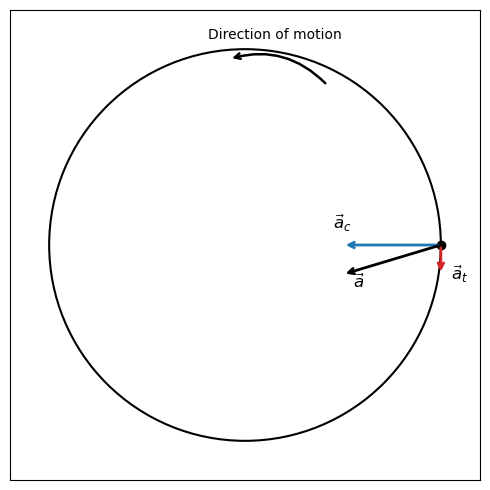

In [31]:
# -----------------------------
# Vector sketch
# -----------------------------
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111,aspect='equal')


point = np.array([1.0, 0.0]) # Point on the rim
# Scaled acceleration vectors for visualization only
ac_vec = np.array([-0.5, 0.0])
at_vec = np.array([0.0, -0.15])
a_vec = ac_vec + at_vec

# Draw the circle
circle = plt.Circle((0, 0), 1.0, fill=False, linewidth=1.5)
ax.add_patch(circle)

# Mark the point
ax.plot(point[0], point[1], 'ko')

end = np.array([np.cos(np.radians(60)), np.sin(np.radians(60))])
start = np.array([np.cos(np.radians(90)), np.sin(np.radians(90))])
ax.annotate("", xy=start + np.array([-0.08, -0.05]), xytext=end + np.array([-0.08, -0.05]), arrowprops=dict(arrowstyle="->", linewidth=1.8,connectionstyle="arc3,rad=0.3"))
# Label
ax.text(0.15, 1.05, "Direction of motion", ha='center')

# Draw centripetal, tangential, and total acceleration vectors
ax.annotate("", xy=point + ac_vec, xytext=point, arrowprops=dict(arrowstyle="->", color='tab:blue', linewidth=2))
ax.annotate("", xy=point + at_vec, xytext=point, arrowprops=dict(arrowstyle="->", color='tab:red', linewidth=2))
ax.annotate("", xy=point + a_vec, xytext=point,  arrowprops=dict(arrowstyle="->", linewidth=2))

# Label the vectors
ax.text(point[0] - 0.55, point[1] + 0.08, r"$\vec{a}_c$", fontsize=12)
ax.text(point[0] + 0.05, point[1] - 0.18, r"$\vec{a}_t$", fontsize=12)
ax.text(point[0] - 0.45, point[1] - 0.22, r"$\vec{a}$", fontsize=12)

# Clean up the axes
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.show()

## Moment of Inertia and Rotational Kinetic Energy

in addition to the description of motion for a rotating rigid body with a fixed axis of rotation, we define two new quantities used in the analysis of rotating objects:

1. momentum of inertia,
2. rotational kinetic energy.

### Rotational Kinetic Energy

Any moving object has kinetic energy, which we found already for a body undergoing translational motion.  *How does this translate to a rigid body undergoing rotation?*

Recall that the tangential velocity $v_t = r\omega$ shows that $v_t$ increases with the radius.  However, the angular velocity $\omega$ can remain the same for the entire rigid body.  

Energy in rotational motion is not a new form of energy, where it is simply an energy related to a specific type of motion. Recall that we defined many types of potential energy (e.g., gravitational or spring).  

- The translational kinetic energy is given by $K = \frac{1}{2}mv^2$, where it would be natural to have a rotational analog.
- Velocity is different for every point on a rotating body about an axis.  For a single particle, this is straightforward to calculate using the relation $v_t = r\omega$.  Through substitution, we find

$$ K = \frac{1}{2} mv_t^2 = \frac{1}{2}m(r\omega)^2 = \frac{1}{2}(mr^2)\omega^2. $$

In the case of a rigid rotating body, we can divide up any body into a large number of smaller masses (each with a mass $m_j$ and distance to the axis of rotation $r_j$), where the total mass of the body is equal to the sum of the individual masses: $M = \displaystyle \sum_j = m_j$.

Each smaller mass has a tangential speed $v_j$, then the total kinetic energy of the rigid rotating body is

$$ K = \frac{1}{2} \sum_j m_j v_j^2 = \frac{1}{2}\sum_j m_j(r_j\omega_j)^2. $$

Since $\omega_j = \omega$ ro all masses, we have

\begin{align}
K = \frac{1}{2} \left(\sum_j m_jr_j^2 \right) \omega^2.
\end{align}

This rotational kinetic energy has units of Joules, just like its translational counterpart.

### Moment of Inertia

Comparing forms for the total kinetic energy, we have

\begin{align*}
K_t &= \frac{1}{2} M v^2, \\
K_r &= \frac{1}{2} \left(\sum_j m_jr_j^2 \right) \omega^2.
\end{align*}

The quantity $\displaystyle \sum_j m_j r_j^2$ is the counterpart for mass in the equation for the rotational kinetic energy.  This quantity is called the **moment of inertia** $I$ (with units of $\rm kg\cdot m^2$):

\begin{align}
I &= \sum_j m_j r_j^2.
\end{align}

The moment of inertia of a single point particle about a fixed axis is simply $mr^2$, where $r$ is the distance from the particle to the axis of rotation.  

The moment of inertia (in general) is the quantitative measure of rotational inertia, similar to mass is the respective quantity for linear inertia.  
- The greater the moment of inertia of a rigid body or system of particles, the greater is its resistance to change in angular velocity about a fixed axis of rotation.
- Rigid bodies and systems of particles with more mass concentrated a greater distance from the axis of rotation have greater moments of inertia.

We can see that a hollow cylinder has more rotational inertia than a solid cylinder of the same mass when rotating about a central axis.  The expression for the rotational kinetic energy can be written in terms of the physical property of the medium $I$, or

\begin{align}
K = \frac{1}{2}I\omega^2.
\end{align}

The kinetic energy of a rotating rigid body is directly proportional to the moment of inertia **and** the square of the angular velocity.  This is exploited in flywheel energy-storage devices, which can store large amounts of rotational kinetic energy.

```{list-table} Rotational vs Translational Kinetic Energy and Inertia
:header-rows: 0
:widths: 20 20

* - **Translational**
  - **Rotational**
* - $m$
  - $I = \sum_j m_j r_j^2$
* - $K = \frac{1}{2} m v^2$
  - $K = \frac{1}{2}I \omega^2$
```

Figure {numref}`{number}<moi-fig>` shows the moment of inertia for common shapes or objects.  The moment of inertia $I$ can be calculated, but this list of common objects is a useful reference.

```{figure-md} moi-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/0082ac16bd654d69e5b521e9df9db699d107220e" alt="moment of inertia diagram"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

#### **Example Problem**: Moment of Inertia for a System of Particles

````{exercise}
:class: etamu-exercise

**The Problem**

>A system consists of six small washers spaced $10\ {\rm cm}$ apart on a rod of negligible mass and $0.5\ {\rm m}$ in length. The mass of each washer is $20\ {\rm g}$. The rod rotates about an axis located at $25\ {\rm cm}$.
>
> (a) What is the moment of inertia of the system?  
> (b) If the two washers closest to the axis are removed, what is the moment of inertia of the remaining four washers?  
> (c) If the system with six washers rotates at $5\ {\rm rev/s}$, what is its rotational kinetic energy?

---

**The Model**

The washers are treated as point masses attached to a rod of negligible mass, so the rod does not contribute to the moment of inertia. The moment of inertia of the system is therefore found by summing the contributions $mr^2$ from each washer, where $r$ is the perpendicular distance from the axis of rotation.

Because all washers have the same mass, the calculation reduces to identifying the set of distances from the axis and summing the corresponding squared distances. Once the moment of inertia is known, the rotational kinetic energy follows from the relation between rotational kinetic energy, moment of inertia, and angular speed.

---

**The Math**

The mass of each washer is

\begin{align*}
m = 20\ {\rm g} = 0.020\ {\rm kg}.
\end{align*}

The six washers are located at distances $0.25\ {\rm m}$, $0.15\ {\rm m}$, and $0.05\ {\rm m}$ from the axis on each side. Therefore, the moment of inertia of the six-washer system is

\begin{align*}
I = \sum_j m_j r_j^2.
\end{align*}

**(a)** The moment of inertia of the full system is

\begin{align*}
I &= (0.020\ {\rm kg})\left[2(0.25\ {\rm m})^2 + 2(0.15\ {\rm m})^2 + 2(0.05\ {\rm m})^2\right] \\
&= 3.5\times 10^{-3}\ {\rm kg\cdot m^2}.
\end{align*}

**(b)** Removing the two washers closest to the axis removes the two contributions at $r=0.05\ {\rm m}$. The moment of inertia of the remaining four washers is therefore

\begin{align*}
I &= (0.020\ {\rm kg})\left[2(0.25\ {\rm m})^2 + 2(0.15\ {\rm m})^2\right] \\
&= 3.4\times 10^{-3}\ {\rm kg\cdot m^2}.
\end{align*}

**(c)** The rotational kinetic energy is determined from

\begin{align*}
K = \frac{1}{2}I\omega^2.
\end{align*}

The angular speed must be expressed in radians per second. Converting $5\ {\rm rev/s}$ gives

\begin{align*}
\omega &= 5\ \frac{\rm rev}{\rm s}\left(\frac{2\pi\ {\rm rad}}{\rm rev}\right) \\
&= 31\ {\rm rad/s}.
\end{align*}

Using the moment of inertia from part (a), the rotational kinetic energy is

\begin{align*}
K &= \frac{1}{2}(0.0035\ {\rm kg\cdot m^2})(31\ {\rm rad/s})^2 \\
&= 1.7\ {\rm J}.
\end{align*}

---

**The Conclusion**

The moment of inertia of the six-washer system is $3.5\times 10^{-3}\ {\rm kg\cdot m^2}$, and the moment of inertia of the remaining four washers is $3.4\times 10^{-3}\ {\rm kg\cdot m^2}$. When the full six-washer system rotates at $5\ {\rm rev/s}$, its rotational kinetic energy is $1.7\ {\rm J}$.

These results show that washers near the axis contribute very little to the total moment of inertia because the factor of $r^2$ strongly reduces their effect. As a result, removing the two washers closest to the axis changes the moment of inertia only slightly.

---

**The Verification**

The Python code verifies the analytical solution by implementing the same particle-model description used in the derivation. The script defines the washer mass and the set of distances from the axis, then computes the moment of inertia by summing the terms $mr^2$ for the full system and for the reduced four-washer system.

The code also converts the angular speed from revolutions per second to radians per second and evaluates the rotational kinetic energy using the moment of inertia from part (a). Because the computation follows the same discrete-particle model and energy relation used in the analytical work, the numerical results reproduce the calculated moments of inertia and rotational kinetic energy.

```python
import numpy as np

m = 0.020 # Mass of each washer (kg)

# (a) Distances for the six-washer system (m)
r_all = np.array([0.25, 0.25, 0.15, 0.15, 0.05, 0.05])

# (b) Distances for the remaining four-washer system (m)
r_four = np.array([0.25, 0.25, 0.15, 0.15])

# (a) Moment of inertia of the six-washer system (kg·m^2)
I_all = np.sum(m * r_all**2)

# (b) Moment of inertia of the remaining four washers (kg·m^2)
I_four = np.sum(m * r_four**2)

# (c) Angular speed and rotational kinetic energy
omega = 5 * 2*np.pi # Angular speed (rad/s)
K = 0.5 * I_all * omega**2 # Rotational kinetic energy (J)

print(f"(a) The moment of inertia of the six-washer system is {I_all:.4f} kg·m^2.")
print(f"(b) The moment of inertia of the remaining four washers is {I_four:.4f} kg·m^2.")
print(f"(c) The rotational kinetic energy of the six-washer system is {K:.1f} J.")
```
````

### Applying Rotational Kinetic Energy

```{admonition} Problem-Solving Strategy
**Rotational Energy**

1. Determine whether an energy or work-energy method is appropriate.
2. Determine the system of interest, where a sketch usually helps.
3. Identify the types of work and energy involved (e.g., translational kinetic energy, rotational kinetic energy, gravitational potential energy).
4. If mechanical energy is conserved (i.e., only conservative work, or frictionless), $K_i + U_i = K_f + U_f$.  Solve for any unknown quantity.
    - If nonconservative forces are present, include them as sources of work that enter or leave the system.
5. Eliminate terms to simplify the algebra.
6. Evaluate the numerical solution to make sure it makes physical sense.
```

#### **Example Problem**: Helicopter Energies

````{exercise}
:class: etamu-exercise

**The Problem**

> A typical small rescue helicopter has four blades. Each is $4.0\ {\rm m}$ long and has a mass of $50\ {\rm kg}$. The blades can be approximated as thin rods that rotate about one end of an axis perpendicular to their length. The helicopter has a total loaded mass of $1000\ {\rm kg}$.
>
> (a) Calculate the rotational kinetic energy in the blades when they rotate at $300\ {\rm rpm}$.  
> (b) Calculate the translational kinetic energy of the helicopter when it flies at $20\ {\rm m/s}$, and compare it with the rotational energy in the blades.

---

**The Model**

Each blade is modeled as a thin rod rotating about one end, so the moment of inertia of one blade is that of a thin rod about its end. Because there are four identical blades, the total moment of inertia is four times the moment of inertia of one blade.

The rotational kinetic energy is determined from the moment of inertia and the angular speed. The translational kinetic energy is determined from the total mass and the linear speed. Comparing the two energies shows how the helicopter’s kinetic energy is distributed between the spinning blades and the motion of the helicopter as a whole.

---

**The Math**

**(a)** The rotational kinetic energy is determined from

\begin{align*}
K_{\rm rot} = \frac{1}{2}I\omega^2.
\end{align*}

The angular speed must be expressed in radians per second. Converting $300\ {\rm rpm}$ gives

\begin{align*}
\omega &= 300\ \frac{\rm rev}{\rm min}\left(\frac{2\pi\ {\rm rad}}{\rm rev}\right)\left(\frac{1\ {\rm min}}{60\ {\rm s}}\right) \\
&= 31\ {\rm rad/s}.
\end{align*}

The moment of inertia of one blade is that of a thin rod rotated about its end:

\begin{align*}
I_{\rm blade} = \frac{1}{3}ML^2.
\end{align*}

The total moment of inertia of the four blades is therefore

\begin{align*}
I &= 4\left(\frac{1}{3}ML^2\right) \\
&= 4\left[\frac{1}{3}(50\ {\rm kg})(4.0\ {\rm m})^2\right] \\
&= 1.1\times10^3\ {\rm kg\cdot m^2}.
\end{align*}

The rotational kinetic energy of the blades is

\begin{align*}
K_{\rm rot} &= \frac{1}{2}(1.1\times10^3\ {\rm kg\cdot m^2})(31\ {\rm rad/s})^2 \\
&= 5.3\times10^5\ {\rm J}.
\end{align*}

**(b)** The translational kinetic energy of the helicopter is determined from

\begin{align*}
K_{\rm trans} = \frac{1}{2}mv^2.
\end{align*}

Using the loaded mass of the helicopter and its flight speed gives

\begin{align*}
K_{\rm trans} &= \frac{1}{2}(1000\ {\rm kg})(20\ {\rm m/s})^2 \\
&= 2.0\times10^5\ {\rm J}.
\end{align*}

The comparison is made by taking the ratio of the translational kinetic energy to the rotational kinetic energy:

\begin{align*}
\frac{K_{\rm trans}}{K_{\rm rot}} &= \frac{2.0\times10^5\ {\rm J}}{5.3\times10^5\ {\rm J}} \\
&= 0.38.
\end{align*}

---

**The Conclusion**

The rotational kinetic energy of the four blades is $5.3\times10^5\ {\rm J}$. The translational kinetic energy of the helicopter is $2.0\times10^5\ {\rm J}$, so the translational energy is only $0.38$ times the rotational energy of the blades.

This result shows that most of the helicopter’s kinetic energy is stored in the spinning blades rather than in the forward motion of the helicopter. The large rotational energy comes from both the large moment of inertia of the blades and their substantial angular speed.

---

**The Verification**

The Python code verifies the analytical solution by implementing the same thin-rod model and kinetic-energy relations used in the derivation. The script converts the blade rotation rate to radians per second, computes the total moment of inertia of the four blades, evaluates the rotational kinetic energy, and then computes the translational kinetic energy of the helicopter.

Because the computation uses the same physical model and energy equations as the analytical work, the numerical results reproduce the calculated rotational energy, translational energy, and their ratio. This agreement confirms that the unit conversion and the energy calculations were carried out consistently.

```python
import numpy as np

L = 4.0 # Blade length (m)
M = 50.0 # Mass of one blade (kg)
n_blades = 4 # Number of blades
rpm = 300 # Angular speed (rpm)
m_heli = 1000 # Loaded helicopter mass (kg)
v = 20.0 # Helicopter speed (m/s)

omega = rpm * 2*np.pi / 60 # (a) Angular speed (rad/s)
I = n_blades * (M * L**2 / 3) # (a) Total moment of inertia of blades (kg·m^2)
K_rot = 0.5 * I * omega**2 # (a) Rotational kinetic energy (J)

K_trans = 0.5 * m_heli * v**2 # (b) Translational kinetic energy (J)
ratio = K_trans / K_rot # (b) Ratio of translational to rotational kinetic energy

print(f"(a) The rotational kinetic energy of the blades is {K_rot:.2e} J.")
print(f"(b) The translational kinetic energy of the helicopter is {K_trans:.2e} J.")
print(f"(b) The ratio K_trans / K_rot is {ratio:.2f}.")
```
````

#### **Example Problem**: Energy in a Boomerang

````{exercise}
:class: etamu-exercise

**The Problem**

> A person hurls a boomerang into the air with a velocity of $30\ {\rm m/s}$ at an angle of $40^\circ$ with respect to the horizontal (Figure {numref}`{number}<boomerang-fig>`). It has a mass of $1.0\ {\rm kg}$ and is rotating at $10\ {\rm rev/s}$. The moment of inertia of the boomerang is given as $I=\frac{1}{12}mL^2$ where $L=0.7\ {\rm m}$.
>
> (a) What is the total energy of the boomerang when it leaves the hand?  
> (b) How high does the boomerang go from the elevation of the hand, neglecting air resistance?


```{figure-md} boomerang-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/5b45b2ae1fb13aecb9feba2228cfb118d7c28ccd" alt="boomerang problem"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

The boomerang has both translational and rotational kinetic energy when it leaves the hand. Its total initial mechanical energy is therefore the sum of these two kinetic energies. The moment of inertia is given, so the rotational kinetic energy can be determined directly once the angular speed is converted to radians per second.

Neglecting air resistance means that the mechanical energy of the boomerang is conserved during its flight. At maximum height, the vertical component of the translational kinetic energy has been converted into gravitational potential energy, while the horizontal translational kinetic energy and the rotational kinetic energy remain unchanged. The height can therefore be determined from conservation of mechanical energy.

---

**The Math**

**(a)** The moment of inertia of the boomerang is given by

\begin{align*}
I = \frac{1}{12}mL^2.
\end{align*}

Using the given mass and length gives

\begin{align*}
I &= \frac{1}{12}(1.0\ {\rm kg})(0.7\ {\rm m})^2 \\
&= 0.041\ {\rm kg\cdot m^2}.
\end{align*}

The angular speed must be written in radians per second. Converting $10\ {\rm rev/s}$ gives

\begin{align*}
\omega &= 10\ \frac{\rm rev}{\rm s}\left(\frac{2\pi\ {\rm rad}}{\rm rev}\right) \\
&= 63\ {\rm rad/s}.
\end{align*}

The rotational kinetic energy is determined from

\begin{align*}
K_{\rm rot} = \frac{1}{2}I\omega^2.
\end{align*}

Using the moment of inertia and angular speed gives

\begin{align*}
K_{\rm rot} &= \frac{1}{2}(0.041\ {\rm kg\cdot m^2})(63\ {\rm rad/s})^2 \\
&= 81\ {\rm J}.
\end{align*}

The translational kinetic energy is determined from

\begin{align*}
K_{\rm trans} = \frac{1}{2}mv^2.
\end{align*}

Using the mass and launch speed gives

\begin{align*}
K_{\rm trans} &= \frac{1}{2}(1.0\ {\rm kg})(30\ {\rm m/s})^2 \\
&= 450\ {\rm J}.
\end{align*}

The total energy when the boomerang leaves the hand is the sum of the rotational and translational kinetic energies:

\begin{align*}
E_{\rm total} &= K_{\rm rot} + K_{\rm trans} \\
&= 81\ {\rm J} + 450\ {\rm J} \\
&= 5.3\times10^2\ {\rm J}.
\end{align*}

**(b)** The vertical component of the launch speed is

\begin{align*}
v_y = v\sin\theta.
\end{align*}

Using the launch speed and angle gives

\begin{align*}
v_y &= (30\ {\rm m/s})\sin 40^\circ \\
&= 19\ {\rm m/s}.
\end{align*}

At maximum height, the vertical translational kinetic energy has been converted into gravitational potential energy. Conservation of mechanical energy therefore gives

\begin{align*}
\frac{1}{2}mv_y^2 = mgh.
\end{align*}

Solving this expression for the height gives

\begin{align*}
h = \frac{v_y^2}{2g}.
\end{align*}

Using $g=9.81\ {\rm m/s^2}$ gives

\begin{align*}
h &= \frac{(19\ {\rm m/s})^2}{2(9.81\ {\rm m/s^2})} \\
&= 18\ {\rm m}.
\end{align*}

---

**The Conclusion**

The total energy of the boomerang when it leaves the hand is $5.3\times10^2\ {\rm J}$. The boomerang rises to a maximum height of $18\ {\rm m}$ above the release point.

This result shows that the boomerang carries substantial rotational energy, but that rotational energy does not affect the maximum height in this idealized model. The height depends only on the vertical component of the launch speed when air resistance is neglected.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same moment of inertia, kinetic energy, and energy-conservation relationships used in the derivation. The script computes the boomerang’s rotational and translational kinetic energies at launch, then uses the vertical launch speed and conservation of mechanical energy to determine the maximum height.

Because the computation implements the same physical model used in the analytical solution, the numerical results reproduce the total launch energy and the maximum height. This agreement confirms that the unit conversion, energy expressions, and launch-speed decomposition were applied consistently.

```python
import numpy as np

m = 1.0 # Mass of the boomerang (kg)
L = 0.7 # Characteristic length in the moment of inertia formula (m)
v = 30.0 # Launch speed (m/s)
theta = np.radians(40) # Launch angle (rad)
rev_per_s = 10 # Angular speed (rev/s)
g = 9.81 # Gravitational acceleration (m/s^2)

I = (1/12) * m * L**2 # (a) Moment of inertia (kg·m^2)
omega = rev_per_s * 2*np.pi # (a) Angular speed (rad/s)
K_rot = 0.5 * I * omega**2 # (a) Rotational kinetic energy (J)
K_trans = 0.5 * m * v**2 # (a) Translational kinetic energy (J)
E_total = K_rot + K_trans # (a) Total launch energy (J)

v_y = v * np.sin(theta) # (b) Vertical launch speed (m/s)
h = v_y**2 / (2*g) # (b) Maximum height above the hand (m)

print(f"(a) The total launch energy of the boomerang is {E_total:.1e} J.")
print(f"(b) The maximum height above the hand is {h:.0f} m.")
```
````

## Calculating Moments of Inertia

There are many applications for using the pre-computed moments of inertia in Fig. {numref}`{number}<moi-fig>`, but there are instances where we need to calculate the moment of inertia for a shifted axis or for a compound object.

(moi_example)= 
### Moment of Inertia

We defined the moment of inertia $I$ of an object as $I = \displaystyle \sum_j = m_j r_j^2$ for all the point masses that make up the object.  Since $r_j$ measures the distance to the axis of rotation (from each mass element $m_j$), the moment of inertia for any object **depends** on the chosen axis.

Consider 2 masses at the end of a massless (or negligibly small mass) rod and calculate the moment of inertia assuming two different rotation axes (see Fig. {numref}`{number}<moi-dumbbell-fig>`).

```{figure-md} moi-dumbbell-fig
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/fe7037e7da5fa71e18f0b23debc2449147a26ea9" alt="moment of inertia dumbbell"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

In this case, the summation over the masses is simple because the two masses can be approximated as point masses, and the sum has only two terms.

1. The axis is in the center of the barbell, where each of the two masses $m$ is a distance $R$ away from the axis, which gives a moment of inertia of

\begin{align*}
I_c &= \sum_j m_j r_j^2, \\
 &= m_1 mr_1^2 + m_2r_2^2, \\
 &= mR^2 + mR^2 = 2mR^2.
\end{align*}

2. The axis is at the end of the barbell, which gives a moment of inertia of

\begin{align*}
I_e &= \sum_j m_j r_j^2, \\
 &= m_1 mr_1^2 + m_2r_2^2, \\
 &= m(0)^2 + m(2R)^2 = 4mR^2.
\end{align*}

*From this result, we can conclude that it is twice as hard to rotate the barbell about the end than about its center.*

Most objects are not point-like, so we need to think about each of the terms in the equation for the moment of inertia.  The equation requires us to sum over each 'piece of mass' $m_j$ that is a distance from the axis of rotation.  Using our calculus knowledge, we break up the problem so that the piece of mass $dm$ is infinitesimally small (see Fig. {numref}`{number}<moi-mass-element>`).

```{figure-md} moi-mass-element
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/c391056c85ecbcbe305cba7a1afe0d46ea68db19" alt="moment of inertia mass element"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

Then we can write the moment of inertia by evaluating an integral over infinitesimal masses rather than using a discrete sum over finite masses;

\begin{align}
I &= \sum_j m_jr_j^2 \quad \Rightarrow \quad I = \int r^2 dm.
\end{align}

In this form, we can generalize the calculation for moment of inertia to complex shapes.

#### A uniform thin rod with axis in the middle

Consider a uniform (in density and shape) thin rod of mass $M$ and length $L$ (see Fig. {numref}`{number}<moi-rod>`).  We want a thin rod so that we can assume the cross-sectional area (i.e., circles at the ends) of the rod is small.  Then the rod can be approximated as a string of masses along a 1D straight line.  The axis is perpendicular to the rod and passes through the midpoint for simplicity.

```{figure-md} moi-rod
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/0fd0ccd8924f047fb7f6c41229be4f8aa2b60d81" alt="moment of inertia rod"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

We need to calculate the moment of inertia about the given axis.  We orient the axes so that it aligns with the $z$ axis and the $x$-axis passes through the length of the rod.  Then we can integrate along the $x$-axis.

We define $dm$ as a small mass element as a piece of the rod.  The moment of inertia integral is an integral over the mass distribution.  However, we need to integrate over space, not mass.  Thus, we need to find a relationship between the mass and spatial variables.

We do this using the **linear mass density** $\lambda$ of the object, which is the mass per unit length.  Since the mass density of the object is uniform, we can spread the mass over the entire length, or

$$ \lambda = \frac{m}{L}, \qquad \text{or} \qquad m = \lambda L. $$

If we take the differential of each side of this equation (i.e., breaking it into mass elements), we find

$$ dm = d(\lambda L) = \lambda\; dL $$

since $\lambda$ is a constant.  We can now see that our orientation of the rod along the $x$-axis for convenience was a helpful choice.

```{note}
A piece of rod $dl$ lies completely along the $x$-axis and has a length $dx$.  In this situation, $dL = dx$.
```

We can therefore write $dm = \lambda\; dx$, which we know how to integrate.  Putting this all together, we have

$$ I = \int r^2 dm = \int x^2 dm = \int x^2\lambda\; dx. $$

The rod extends from $x = -L/2$ to $x=L/2$, since the axis lies in the middle of the rod (at $x=0$).  Then we have

\begin{align*}
I &= \int_{-L/2}^{L/2} x^2\lambda\; dx = \frac{\lambda}{3}x^3 \bigg\vert_{-L/2}^{L/2}, \\
&= \frac{\lambda}{3}\left[ \left(\frac{L}{2}\right)^3 - \left(-\frac{L}{2}\right)^3 \right], \\
&= \frac{\lambda}{3}\left[ \frac{2L^3}{2^3}\right] = \frac{\lambda}{12}L^3.
\end{align*}

Since $\lambda = \frac{M}{L}$, we can substitute to find

$$ I = \frac{1}{12}ML^2. $$

We can compare to Fig. {numref}`{number}<moi-fig>` and see that our result matches the case for a *'Thin rod about axis through center $\perp$ to length'*.

#### A uniform thin rod with axis at the end

Consider a uniform (in density and shape) then rod of mass $M$ and length $L$ as before, but this time we move the axis of rotation to the end of the rod (see Fig. {numref}`{number}<moi-rod-end>`).  

```{figure-md} moi-rod-end
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/f64b1f70822a00d990eb24df71df7207d65a0599" alt="moment of inertia rod axis at end"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

The only difference from before is the limits of integration, which is now from $x=0$ to $x=L$.  Thus, we can start from the integration step to get:

\begin{align*}
I &= \int_{0}^{L} x^2\lambda\; dx = \frac{\lambda}{3}x^3 \bigg\vert_{0}^{L}, \\
&= \frac{\lambda}{3}\left[ L^3 - 0^3 \right], \\
&= \frac{\lambda}{3}L^3 = \frac{1}{3}ML^2.
\end{align*}

```{note}
The rotational inertia of the rod about its endpoint is larger than about its center by a factor of four.  This is consistent with the barbell example in {numref}`moi_example`.
```

### The Parallel-Axis Theorem

The process between finding the moment of inertia of a rod using two different axes had mostly the same steps.  This suggests that there might be a simpler method for determining the moment of inertia for a rod about *any* parallel axis through the center-of-mass.  This is called the **parallel-axis theorem**.

```{admonition} Parallel-axis Theorem
:class: note

Let $m$ be the mass of an object, while $d$ is the distance from an axis through the object's center-of-mass to a new axis.  Then we have

\begin{align}
I_\parallel = I_{\rm CoM} + md^2,
\end{align}

where $I_\parallel$ is the moment of inertia for the parallel axis and $I_{\rm CoM}$ is the moment of inertia through the center-of-mass.
```

Let's use the case where the axis lies at the center of the rod, which is $I_{\rm CoM} = \frac{1}{12} ML^2$.  Then, we can move the axis by a distance of $\frac{L}{2}$ so that the the axis now lies a the the end of the rod.  As a result, we find

\begin{align*}
I_\parallel &= \frac{1}{12}ML^2 + m\left(\frac{L}{2}\right)^2, \\
&= \left[\frac{1}{12} + \frac{1}{4}\right] ML^2, \\
&= \frac{4}{12}ML^2 = \frac{1}{3}ML^2. \checkmark
\end{align*}

#### A uniform thin disk about an axis through the center

Integrating to find the moment of inertia for a 2D object is trickier, but one shape is commonly show is a uniform thin disk about an axis through its center (see Fig. {numref}`{number}<moi-disk>`).

```{figure-md} moi-disk
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/ccd444ab38cabf2b0d75b7baef135d155e8f256d" alt="moment of inertia for a disk"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

Since the disk is thin, we can take the mass as distributed evenly across the entire $xy$-plane.  Instead of a linear mass density, we have a relationship for the **surface mass density** (or mass per unit surface area).  The surface mass density $\sigma$ is constant for a thin disk:

\begin{align*}
\sigma &= \frac{m}{A}\quad \Rightarrow \quad \sigma A = m, \\
dm &= \sigma\; dA.
\end{align*}

We apply a simplification for the area, where it is composed of a series of thin rings.  Each ring has a mass increment $dm$ of radius $r$ that is equidistant from the axis.  The infinitesimal area of each ring is $dA$ with a length $2\pi r$ time the infinitesimal width of each ring as dr.

We can break the area of a circle in to smaller pieces by

\begin{align*}
A &= \pi r^2,\\
dA &= d(\pi r^2) = \pi d(r^2) = (2\pi r) dr.
\end{align*}

The full disk area is then built by summing up all the thin rings with a radius range from $r=0$ to $r=R$.  This radius range becomes our limits of integration for $dr.  Putting this all together, we have

\begin{align*}
I &= \int_0^R r^2\sigma\, dA = \int_0^R r^2\sigma (2\pi r)dr, \\
&= 2\pi\sigma \int_0^R r^3 dr = \frac{\pi\sigma}{2}r^4\bigg\vert|_0^R, \\
&= \frac{\pi}{2}\sigma R^4.
\end{align*}

Then, we can substitute $\sigma = \frac{m}{A}$ and for a disk, we have $\sigma = \frac{m}{\pi R^2}.  Thus we obtain

$$ I = \frac{\pi}{2}\left(\frac{m}{\pi R^2}\right) R^4 = \frac{1}{2}m R^2.$$

We can compare to Fig. {numref}`{number}<moi-fig>` and see that our result matches the case for a *'Hoop about any diameter'*.

#### Calculating the moment of Inertia for compound objects

Consider a compound object with a disk on the end of a rod (see Fig. {numref}`{number}<moi-compound>`).  This object is not uniformly shaped, so the integration is not so easy.

```{figure-md} moi-compound
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/9550351bf1259b401009fb0bdb5ebdbddba1876a" alt="moment of inertia for compound object"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

However, if we use the definition for the moment of inertia as a summation, we can reason that a compound object's moment of inertia can be determined as the sum of each part of the object:

\begin{align}
I_{\rm tot} = \sum_j I_j.
\end{align}

```{note}
The moments of inertia must share a common axis.  
```

In the above example, this would a rod of length rotating about its end and a thin disk of radius $R$ rotating about an axis shifted off-center by a distance $L+R$, where $R$ is the radius of the disk.  The mass of the rod is $m_r$, while the mass of the disk is $m_d$. 

We already know the moment of inertia for the rod as $\frac{1}{2}m_rL^2$, but we have to use the parallel-axis theorem to the find the moment of inertia for the disk about the given axis. The moment of inertia of the disk about its center-of-mass is $\frac{1}{2}m_dR^2$.  Now we can apply the parallel-axis theorem to get

\begin{align*}
I_\parallel &= I_{\rm CoM} + md^2, \\
&= \frac{1}{2}m_dR^2 + m_d(L+R)^2.
\end{align*}

Adding the moment of inertia of the rod to the moment of inertia of the disk (with a shifted axis of rotation), we find the moment of inertia for the compound object is

$$ I_{\rm tot} = \frac{1}{3}m_rL^2 + \frac{1}{2}m_dR^2 + m_d(L+R)^2. $$

```{note}
We could expand the above result to collect terms in $m_dR^2$, however the overall number of terms would be larger.  There would be an additional $m_dL^2 + 2m_dLR$ from expanding the square.  Resulting in four terms, which does not really make it any simpler.
``` 


### **Example Problem**: Person on a Merry-Go-Round

````{exercise}
:class: etamu-exercise

**The Problem**

> A $25\ {\rm kg}$ child stands at a distance $r=1.0\ {\rm m}$ from the axis of a rotating merry-go-round. The merry-go-round can be approximated as a uniform solid disk with a mass of $500\ {\rm kg}$ and a radius of $2.0\ {\rm m}$. Find the moment of inertia of this system.

---

**The Model**

The system consists of two parts: the child and the merry-go-round. The child is modeled as a point mass located $1.0\ {\rm m}$ from the axis, and the merry-go-round is modeled as a uniform solid disk rotating about its center.

The total moment of inertia of the system is the sum of the moment of inertia of the child and the moment of inertia of the disk.

---

**The Math**

The moment of inertia of the child is given by the point-mass expression $I_c = mr^2.$  Using the mass and distance of the child gives

\begin{align*}
I_c &= (25\ {\rm kg})(1.0\ {\rm m})^2 \\
&= 25\ {\rm kg\cdot m^2}.
\end{align*}

The moment of inertia of the merry-go-round is given by the uniform-disk expression

\begin{align*}
I_m = \frac{1}{2}MR^2.
\end{align*}

Using the mass and radius of the merry-go-round gives

\begin{align*}
I_m &= \frac{1}{2}(500\ {\rm kg})(2.0\ {\rm m})^2 \\
&= 1000\ {\rm kg\cdot m^2}.
\end{align*}

The total moment of inertia of the system is the sum of these two contributions:

\begin{align*}
I_{\rm total} &= I_c + I_m \\
&= 25\ {\rm kg\cdot m^2} + 1000\ {\rm kg\cdot m^2} \\
&= 1025\ {\rm kg\cdot m^2} \approx 1000\ {\rm kg\cdot m^2}.
\end{align*}

---

**The Conclusion**

The moment of inertia of the child–merry-go-round system is $1000\ {\rm kg\cdot m^2}$.

This result shows that the total moment of inertia is dominated by the merry-go-round rather than the child. The disk contributes much more because it has far more mass distributed over a larger radius.

---

**The Verification**

The Python code verifies the analytical solution by computing the two separate moment-of-inertia contributions and then summing them to obtain the total for the system. The script uses the point-mass model for the child and the uniform-disk model for the merry-go-round, so it mirrors the same physical model used in the derivation.

```python
import numpy as np

m_c = 25 # Child mass (kg)
r_c = 1.0 # Child distance from axis (m)
m_m = 500 # Merry-go-round mass (kg)
R_m = 2.0 # Merry-go-round radius (m)

I_c = m_c * r_c**2 # Moment of inertia of the child (kg·m^2)
I_m = 0.5 * m_m * R_m**2 # Moment of inertia of the merry-go-round (kg·m^2)
I_total = I_c + I_m # Total moment of inertia of the system (kg·m^2)

print(f"The child's moment of inertia is {I_c:.0f} kg·m^2.")
print(f"The merry-go-round's moment of inertia is {I_m:.0f} kg·m^2.")
print(f"The total moment of inertia of the system is {I_total:.0f} kg·m^2.")
```
````

### **Example Problem**: Rod and Solid Sphere

````{exercise}
:class: etamu-exercise

**The Problem**

> Find the moment of inertia of the rod and solid sphere combination about the two axes as shown below. The rod has length $0.5\ {\rm m}$ and mass $2.0\ {\rm kg}$. The radius of the sphere is $20\ {\rm cm}$ and the sphere has mass $1.0\ {\rm kg}$.
>
> (a) Find the moment of inertia about the axis through point $A$ at the top of the rod.  
> (b) Find the moment of inertia about the axis through point $A$ at the junction of the rod and the sphere.

```{figure-md} rod-sphere-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/dfa57da8cd6a9b06d0d47908ebf4d0134fcd3afa" alt="rod and sphere problem"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

The object is a compound system consisting of a slender rod and a solid sphere. The total moment of inertia about either axis is the sum of the moment of inertia of the rod and the moment of inertia of the sphere about that same axis.

The rod rotates about an axis through one end, so its contribution is found using the standard result for a thin rod about one end. The sphere rotates about an axis that does not pass through its center, so its contribution is found using the parallel-axis theorem. The distance from the sphere’s center to the rotation axis depends on which of the two axes is chosen.

---

**The Math**

The total moment of inertia is the sum of the rod and sphere contributions:

\begin{align*}
I_{\rm total} = I_{\rm rod} + I_{\rm sphere}.
\end{align*}

The rod rotates about an axis through one end, so its moment of inertia is

\begin{align*}
I_{\rm rod} &= \frac{1}{3}m_{\rm rod}L^2, \\
&= \frac{1}{3}(2.0\ {\rm kg})(0.5\ {\rm m})^2 \\
&= 0.17\ {\rm kg\cdot m^2}.
\end{align*}

The sphere is a solid sphere, so its moment of inertia about its center of mass is

\begin{align*}
I_{\rm cm} &= \frac{2}{5}m_{\rm sphere}R^2, //
I_{\rm cm} &= \frac{2}{5}(1.0\ {\rm kg})(0.20\ {\rm m})^2 \\
&= 0.016\ {\rm kg\cdot m^2}.
\end{align*}

**(a)** The axis is at the top of the rod. The center of the sphere is therefore a distance $L+R$ from the axis. The parallel-axis theorem gives

\begin{align*}
I_{\rm sphere} &= I_{\rm cm} + m_{\rm sphere}(L+R)^2, //
&= 0.016\ {\rm kg\cdot m^2} + (1.0\ {\rm kg})(0.5\ {\rm m}+0.20\ {\rm m})^2 \\
&= 0.016\ {\rm kg\cdot m^2} + 0.49\ {\rm kg\cdot m^2} \\
&= 0.51\ {\rm kg\cdot m^2}.
\end{align*}

The total moment of inertia is therefore

\begin{align*}
I_{\rm total} &= 0.17\ {\rm kg\cdot m^2} + 0.51\ {\rm kg\cdot m^2} \\
&= 0.68\ {\rm kg\cdot m^2}.
\end{align*}

**(b)** The axis is at the junction of the rod and the sphere. The center of the sphere is therefore a distance $R$ from the axis. The parallel-axis theorem gives

\begin{align*}
I_{\rm sphere} &= I_{\rm cm} + m_{\rm sphere}R^2, //
&= 0.016\ {\rm kg\cdot m^2} + (1.0\ {\rm kg})(0.20\ {\rm m})^2 \\
&= 0.016\ {\rm kg\cdot m^2} + 0.040\ {\rm kg\cdot m^2} \\
&= 0.056\ {\rm kg\cdot m^2}.
\end{align*}

The total moment of inertia is therefore

\begin{align*}
I_{\rm total} &= 0.17\ {\rm kg\cdot m^2} + 0.056\ {\rm kg\cdot m^2} \\
&= 0.23\ {\rm kg\cdot m^2}.
\end{align*}

---

**The Conclusion**

The moment of inertia of the rod–sphere system is $0.68\ {\rm kg\cdot m^2}$ about the axis through the top of the rod, and it is $0.23\ {\rm kg\cdot m^2}$ about the axis through the junction of the rod and sphere.

These results show that the moment of inertia is larger when the axis is farther from the mass of the sphere. Moving the axis closer to the center of mass of the system reduces the resistance to rotational acceleration.

---

**The Verification**

The Python code verifies the analytical solution by computing the rod contribution directly and then applying the parallel-axis theorem to the sphere for each axis location. The script uses the same geometric distances from the sphere’s center to the rotation axis that were used in the derivation.

Because the computation implements the same compound-body model and the same parallel-axis reasoning, the numerical results reproduce the two moments of inertia found analytically. This agreement confirms that the geometry and the additive structure of the moment of inertia were handled consistently.

```python
import numpy as np

L = 0.5 # Rod length (m)
m_rod = 2.0 # Rod mass (kg)
R = 0.20 # Sphere radius (m)
m_sphere = 1.0 # Sphere mass (kg)

I_rod = (1/3) * m_rod * L**2 # Rod moment of inertia about one end (kg·m^2)
I_cm = (2/5) * m_sphere * R**2 # Sphere moment of inertia about its center (kg·m^2)

d_a = L + R # (a) Distance from sphere center to top axis (m)
I_sphere_a = I_cm + m_sphere * d_a**2 # (a) Sphere contribution (kg·m^2)
I_total_a = I_rod + I_sphere_a # (a) Total moment of inertia (kg·m^2)

d_b = R # (b) Distance from sphere center to junction axis (m)
I_sphere_b = I_cm + m_sphere * d_b**2 # (b) Sphere contribution (kg·m^2)
I_total_b = I_rod + I_sphere_b # (b) Total moment of inertia (kg·m^2)

print(f"(a) The total moment of inertia about the top axis is {I_total_a:.2f} kg·m^2.")
print(f"(b) The total moment of inertia about the junction axis is {I_total_b:.2f} kg·m^2.")
```
````

### **Example Problem**: Angular velocity of a Pendulum

````{exercise}
:class: etamu-exercise

**The Problem**

> A pendulum in the shape of a rod (Figure {numref}`{number}<pendulum-problem>`) is released from rest at an angle of $30^\circ$. It has a length $30\ {\rm cm}$ and mass $300\ {\rm g}$. What is its angular velocity at its lowest point?


```{figure-md} pendulum-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/8e70caad598e1f669ec76892f19a5a4292a4f5d0" alt="pendulum problem"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```
---

**The Model**

The pendulum is modeled as a uniform rod rotating about one end. Because it is released from rest and air resistance is neglected, the mechanical energy of the system is conserved during the motion.

As the rod swings downward, the loss in gravitational potential energy of its center of mass is converted into rotational kinetic energy. The center of mass of a uniform rod is located at its midpoint, and the moment of inertia of a uniform rod about one end is used to relate the rotational kinetic energy to the angular velocity.

---

**The Math**

The rod has length $L=30\ {\rm cm}=0.30\ {\rm m}$. The center of mass of a uniform rod is located at a distance $L/2$ from the pivot. When the rod is released from an angle $\theta$, the vertical drop of the center of mass between the release point and the lowest point is

\begin{align*}
\Delta h = \frac{L}{2}(1-\cos\theta).
\end{align*}

The loss in gravitational potential energy is therefore (see [Exercise 8.7](https://saturnaxis.github.io/IntroPhysics/Chapter08/potential-energy-conservation.html#example-problem-simple-pendulum))

\begin{align*}
\Delta U = mg\frac{L}{2}(1-\cos\theta).
\end{align*}

At the lowest point, the rod has rotational kinetic energy via

\begin{align*}
K = \frac{1}{2}I\omega^2.
\end{align*}

Conservation of mechanical energy requires that the loss in gravitational potential energy equals the gain in rotational kinetic energy, which gives

\begin{align*}
mg\frac{L}{2}(1-\cos\theta) = \frac{1}{2}I\omega^2.
\end{align*}

The moment of inertia of a uniform rod about one end is $I = \frac{1}{3}mL^2.$  Substituting this expression into the energy equation gives

\begin{align*}
mg\frac{L}{2}(1-\cos\theta) &= \frac{1}{2}\left(\frac{1}{3}mL^2\right)\omega^2.
\end{align*}

We must now solve for the angular velocity, which gives

\begin{align*}
\omega &= \sqrt{\frac{3g}{L}(1-\cos\theta)}.
\end{align*}

Using $g=9.81\ {\rm m/s^2}$, $L=0.30\ {\rm m}$, and $\theta=30^\circ$ gives

\begin{align*}
\omega &= \sqrt{\frac{3(9.81\ {\rm m/s^2})}{0.30\ {\rm m}}(1-\cos 30^\circ)} \\
&= 3.6\ {\rm rad/s}.
\end{align*}

---

**The Conclusion**

The angular velocity of the rod at its lowest point is $3.6\ {\rm rad/s}$.

This result shows that the angular speed depends on the geometry of the rod and the release angle, but not on the mass of the rod. In this idealized model, the mass cancels because both the gravitational potential energy and the rotational kinetic energy are proportional to the mass.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same energy-conservation relationship used in the derivation. The script computes the angular velocity from the closed-form expression obtained by combining the gravitational potential-energy change with the rotational kinetic-energy expression for a uniform rod about one end.

Because the computation implements the same physical model used in the analytical solution, the numerical result reproduces the calculated angular velocity at the lowest point. This agreement confirms that the energy method and the moment-of-inertia substitution were applied consistently.

```python
import numpy as np

L = 0.30 # Rod length (m)
theta = np.radians(30) # Release angle (rad)
g = 9.81 # Gravitational acceleration (m/s^2)

omega = np.sqrt((3 * g / L) * (1 - np.cos(theta))) # Angular velocity at the lowest point (rad/s)

print(f"The angular velocity of the pendulum at its lowest point is {omega:.1f} rad/s.")
```
````

## Torque

An important quantity for describing the dynamics of a rotating rigid body is *torque*.  We have an intuition about torque, as when we use a large wrench to unscrew a bolt.  Torque also appears when we press on the accelerator in a car causing the engine to spin-up the drive train faster.

### Defining Torque

Since we have found rotational counterparts for the kinematic equations and variables, we should expect there to be a counterpart to force.  Forces change the translational motion of objects, thus the rotational counterpart must be related to changing the rotational motion of an object about an axis.  We formally define this quantity as **torque**.

Consider how we rotate a door to open it.  Let's write down what we know from experience (and the implications):

1. A door opens slowly if we push too close to its hinges.  It is more efficient to rotate a door open if we push far from the hinges.
    - The farther the force is applied from the axis of rotation, the greater the *angular acceleration*.
2. We should push perpendicular to the plane of the door.  If we push parallel to the plane of the door, we are not able to rotate it.
    - The effectiveness *depends on the angle* at which the force is applied.
3. The larger the force, the more effective it is in opening the door (i.e., the more rapidly it opens).
    - The magnitude of the force must also be part of the equation.

```{note}
For a rotation in a plane, there are two possible directions for the rotation: clockwise or counterclockwise.  Following the convention that counterclockwise is positive, then clockwise rotation is negative.
```

Figure {numref}`{number}<door-force-example>` illustrates 4 different ways that we could apply a force to a door.  Note that the door will rotate relative to the pivot in a counterclockwise direction.

```{figure-md} door-force-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/59d08861276142d4086ec57210894bc3cad209a7" alt="examples of force applied on a door"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

```{admonition} Torque
:class: note

When a force $\vec{F}$ is applied to a point $P$ whose position is $\vec{r}$ relative to the pivot point $O$, the torque $\vec{\tau}$ is given by

\begin{align}
\vec{\tau} = \vec{r} \times \vec{F}.
\end{align}

```

Figure {numref}`{number}<torque-hand-example>` illustrates how the direction of the torque can be found using the `right-had rule`.  This naturally comes from our definitions using the cross-product.

```{figure-md} torque-hand-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/417d9e7c40b259ad1f86074b51a1848e0ef729cf" alt="right-hand rule for torque"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```


From the definition of the cross product, the torque $\vec{\tau}$ is perpendicular to the plane containing $\vec{r}$ and $\vec{F}$.  The torque has a magnitude

$$ |\vec{\tau}| = |\vec{r} \times \vec{F}| = rF\sin{\theta}, $$

where $\theta$ is the angle between the vectors $\vec{r}$ and $\vec{F}$.  The SI unit for torque is newtons times meters (usually written as $\rm N\cdot m$), where this does **not** reduce to Joules as was the case for work.

The quantity $r_\perp=r\sin{\theta}$ is the perpendicular distance from $O$ to the line determined by the vector $\vec{F}$ and is called the **lever arm**.  
- The greater the lever arm, the greater the magnitude of the torque.

In terms of the lever arm, the magnitude of the torque is

\begin{align}
|\vec{\tau}| = r_\perp F. 
\end{align}

The cross product tells us the sign of the torque.
- In Fig. {numref}`{number}<torque-disk-example>`, there is a positive torque because the cross product is along the $z$-axis.
- If the torque is along the negative $z$-axis, then the torque is negative.

```{figure-md} torque-disk-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/417d9e7c40b259ad1f86074b51a1848e0ef729cf" alt="torque on a disk"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

If we consider a disk that is free to rotate about an axis through the center (see Fig. {numref}`{number}<torque-disk-example>`), we can see how the angle between the radius $\vec{r}$ and force $\vec{F}$ affects the magnitude of the torque.

- If the angle is zero, then the torque is zero.
- If the angle is $90^\circ$, then the torque is at a maximum.

Any number of torques can be calculated about a given axis, where the individual torques add to produce a net torque about the axis.  When the appropriate sign is applied to the magnitudes of individual torques about a specified axis, the net torque about the axis is the sum of the individual torques, or

\begin{align}
\vec{\tau}_{\rm net} = \sum_j \vec{\tau}_j.
\end{align}

```{admonition} Problem-Solving Strategy
:class: note

**Finding Net Torque**

1. Choose a coordinate system with the pivot point or axis as the origin.
2. Determine the angle between the lever arm $\vec{r}$ and the force $\vec{F}$.
3. Take the cross product of $\vec{r}$ and $\vec{F}$ to determine if the torque is positive or negative about the pivot point.
4. Evaluate the magnitude of the torque using $r_\perp F$.
5. Assign the appropriate sign (positive or negative) to the magnitude.
6. Sum the torques to find the net torque.
```

### **Example Problem**: Torque on Particles

````{exercise}
:class: etamu-exercise

**The Problem**

> Four forces are shown in Figure {numref}`{number}<torque-particles-problem>` at particular locations and orientations with respect to a given $xy$-coordinate system. Find the torque due to each force about the origin, then use your results to find the net torque about the origin.

```{figure-md} torque-particles-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/1543e58e041e2e3fa6ba48e091b1a35926e25da9" alt="torque on particles"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

Each torque is determined from the force, its location relative to the origin, and the angle between the position vector and the force. The magnitude of each torque is found from the perpendicular lever arm or, equivalently, from $|\vec{\tau}| = rF\sin\theta$.

The sign of each torque is determined from the direction of $\vec{r}\times\vec{F}$. A torque that points out of the page is positive, corresponding to counterclockwise rotation, and a torque that points into the page is negative, corresponding to clockwise rotation. The net torque is the algebraic sum of the individual torques.

---

**The Math**

The magnitude of the torque due to a force about the origin is $|\vec{\tau}| = rF\sin\theta.$  The sign of the torque is determined from the cross product $\vec{r}\times\vec{F}$.

The $40\ {\rm N}$ force acts upward at $x=4\ {\rm m}$, so the lever arm is $4\ {\rm m}$ and the angle between $\vec{r}$ and $\vec{F}$ is $90^\circ$. The torque from this force is

\begin{align*}
\tau_1 &= (4\ {\rm m})(40\ {\rm N})\sin 90^\circ \\
&= 160\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}$ points out of the page, so this torque is positive.

The $20\ {\rm N}$ force at $y=-3\ {\rm m}$ acts horizontally to the left, so the lever arm is $3\ {\rm m}$ and the angle between $\vec{r}$ and $\vec{F}$ is $90^\circ$. The torque from this force is

\begin{align*}
\tau_2 &= (3\ {\rm m})(20\ {\rm N})\sin 90^\circ \\
&= 60\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}$ points into the page, so this torque is negative:

\begin{align*}
\tau_2 = -60\ {\rm N\cdot m}.
\end{align*}

The $30\ {\rm N}$ force is applied at a distance $5\ {\rm m}$ from the origin, and the angle between $\vec{r}$ and $\vec{F}$ is $53^\circ$. The torque from this force is

\begin{align*}
\tau_3 &= (5\ {\rm m})(30\ {\rm N})\sin 53^\circ \\
&= 120\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}$ points out of the page, so this torque is positive.

The $20\ {\rm N}$ force in the second quadrant is applied at a distance $1\ {\rm m}$ from the origin, and the angle between $\vec{r}$ and $\vec{F}$ is $30^\circ$. The torque from this force is

\begin{align*}
\tau_4 &= (1\ {\rm m})(20\ {\rm N})\sin 30^\circ \\
&= 10\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}$ points out of the page, so this torque is positive.

The net torque is the algebraic sum of the four torques:

\begin{align*}
\tau_{\rm net} &= \tau_1 + \tau_2 + \tau_3 + \tau_4 \\
&= 160\ {\rm N\cdot m} - 60\ {\rm N\cdot m} + 120\ {\rm N\cdot m} + 10\ {\rm N\cdot m} \\
&= 230\ {\rm N\cdot m}.
\end{align*}

---

**The Conclusion**

The individual torques about the origin are $+160\ {\rm N\cdot m}$, $-60\ {\rm N\cdot m}$, $+120\ {\rm N\cdot m}$, and $+10\ {\rm N\cdot m}$. The net torque about the origin is $230\ {\rm N\cdot m}$.

This result shows that the counterclockwise torques dominate the clockwise torque, so the net tendency is counterclockwise rotation. It also illustrates that torque depends on both the force magnitude and the perpendicular distance from the axis.

---

**The Verification**

The Python code verifies the analytical solution by computing the torque from each force using the same magnitude relation and sign convention used in the derivation. The script stores the individual torque values with their signs, then adds them algebraically to determine the net torque.

Because the computation follows the same torque model and sign convention used in the analytical work, the numerical results reproduce the individual torques and the net torque. This agreement confirms that the lever arms, force components, and torque directions were handled consistently.

```python
import numpy as np

tau1 = 4 * 40 * np.sin(np.radians(90)) # Torque from 40 N force (N·m)
tau2 = -3 * 20 * np.sin(np.radians(90)) # Torque from 20 N force at y = -3 m (N·m)
tau3 = 5 * 30 * np.sin(np.radians(53)) # Torque from 30 N force (N·m)
tau4 = 1 * 20 * np.sin(np.radians(30)) # Torque from 20 N force in second quadrant (N·m)

tau_net = tau1 + tau2 + tau3 + tau4 # Net torque (N·m)

print(f"The torque from the 40 N force is {tau1:.0f} N·m.")
print(f"The torque from the 20 N force at y = -3 m is {tau2:.0f} N·m.")
print(f"The torque from the 30 N force is {tau3:.0f} N·m.")
print(f"The torque from the 20 N force in the second quadrant is {tau4:.0f} N·m.")
print(f"The net torque about the origin is {tau_net:.0f} N·m.")
```
````

### **Example Problem**: Torque on a Rigid Body

````{exercise}
:class: etamu-exercise

**The Problem**

> Figure {numref}`{number}<torque-flywheel-problem>` shows several forces acting at different locations and angles on a flywheel. We have $|\vec{F}_1|=20\ {\rm N}$, $|\vec{F}_2|=30\ {\rm N}$, $|\vec{F}_3|=30\ {\rm N}$, and $r=0.5\ {\rm m}$.
>
> Find the net torque on the flywheel about an axis through the center.

```{figure-md} torque-flywheel-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/eef3c769d2b445a9d571403dc8d255b7973a6ca3" alt="torque on a rigid body"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

Each torque is determined from the position vector from the center of the flywheel to the point of application and the corresponding force. The magnitude of each torque is found from $|\vec{\tau}| = rF\sin\theta$, where $\theta$ is the angle between $\vec{r}$ and $\vec{F}$.

The sign of each torque is determined from the direction of $\vec{r}\times\vec{F}$. A torque that points out of the page is positive, corresponding to counterclockwise rotation, and a torque that points into the page is negative, corresponding to clockwise rotation. The net torque is the algebraic sum of the individual torques.

---

**The Math**

The magnitude of the torque due to a force about the center is $|\vec{\tau}| = rF\sin\theta.$  The torque due to $\vec{F}_1$ is determined from the angle between $\vec{r}$ and $\vec{F}_1$. The figure shows that this angle is $150^\circ$, so the torque magnitude is

\begin{align*}
|\vec{\tau}_1| &= (0.5\ {\rm m})(20\ {\rm N})\sin 150^\circ \\
&= 5.0\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}_1$ points out of the page, so this torque is positive:

\begin{align*}
\tau_1 = +5.0\ {\rm N\cdot m}.
\end{align*}

The torque due to $\vec{F}_2$ is determined from the angle between $\vec{r}$ and $\vec{F}_2$. The figure shows that this angle is $90^\circ$, so the torque magnitude is

\begin{align*}
|\vec{\tau}_2| &= (0.5\ {\rm m})(30\ {\rm N})\sin 90^\circ \\
&= 15.0\ {\rm N\cdot m}.
\end{align*}

The cross product $\vec{r}\times\vec{F}_2$ points into the page, so this torque is negative:

\begin{align*}
\tau_2 = -15.0\ {\rm N\cdot m}.
\end{align*}

The force $\vec{F}_3$ acts along the same line as the radius vector, so the angle between $\vec{r}$ and $\vec{F}_3$ is $0^\circ$. Therefore,

\begin{align*}
\tau_3 &= (0.5\ {\rm m})(30\ {\rm N})\sin 0^\circ \\
&= 0.
\end{align*}

The net torque is the algebraic sum of the three torques:

\begin{align*}
\tau_{\rm net} &= \tau_1 + \tau_2 + \tau_3 \\
&= 5.0\ {\rm N\cdot m} - 15.0\ {\rm N\cdot m} + 0 \\
&= -10\ {\rm N\cdot m}.
\end{align*}

---

**The Conclusion**

The net torque on the flywheel about its center is $-10\ {\rm N\cdot m}$.  The negative sign shows that the net tendency is clockwise rotation. This result also illustrates that a force applied directly along the radius does not produce torque because it has no perpendicular lever arm.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the torque from each force using the same magnitude relation and sign convention used in the derivation. The script computes the three torques from the given radius, force magnitudes, and angles, then adds them algebraically to determine the net torque.

Because the computation follows the same torque model and sign convention used in the analytical work, the numerical results reproduce the individual torques and the net torque. This agreement confirms that the force directions, torque signs, and angle choices were handled consistently.

```python
import numpy as np

r = 0.5 # Radius from the center to each point of application (m)
F1 = 20 # Magnitude of F1 (N)
F2 = 30 # Magnitude of F2 (N)
F3 = 30 # Magnitude of F3 (N)

tau1 = r * F1 * np.sin(np.radians(150)) # Torque from F1 (N·m)
tau2 = -r * F2 * np.sin(np.radians(90)) # Torque from F2 (N·m)
tau3 = r * F3 * np.sin(np.radians(0)) # Torque from F3 (N·m)

tau_net = tau1 + tau2 + tau3 # Net torque (N·m)

print(f"The torque due to F1 is {tau1:.1f} N·m.")
print(f"The torque due to F2 is {tau2:.1f} N·m.")
print(f"The torque due to F3 is {tau3:.1f} N·m.")
print(f"The net torque on the flywheel is {tau_net:.0f} N·m.")
```
````

## Newton's 2nd Law for Rotation

### Defining Newton's 2nd Law for Rotation in Vector Form

Since torque is a rotational analog to force, *is there an analogous equation to Newton's 2nd law?*

Let's start with Newton's 2nd law for a single particle rotating around an axis in circular motion.  A force $\vec{F}$ is applied on a point mass $m$ that is a distance $r$ from a pivot point (see Fig. {numref}`{number}<torque-force-example>`).

```{figure-md} torque-force-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/2fb4c8f82838c715c456e82922c2aa19370c2013" alt="torque on a mass"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

The particle is constrained to move in a circular path with a fixed radius and the force is tangent to the path.  We apply Newton's 2nd law to determine the magnitude of the acceleration $(a = \frac{F}{m})$ in the direction of $\vec{F}$.  Since the force is *tangential* to the path, we can use the relation for the tangential acceleration that relates to the angular acceleration ($a=r\alpha$).  

Substituting this expression into Newton's 2nd law, we have

\begin{align*}
F &= ma,\\
&= mr\alpha.
\end{align*}

We can multiply both sides by the radius $r$, which is motivated by the form of the torque, $\tau = rF\sin{\theta}$.  The force is applied perpendicular to $r$, thus $\sin{\theta} = 1$.  Now we have,

\begin{align*}
rF &= mr^2\alpha,\\
\tau &= (mr^2)\alpha, \\
&= I\alpha.
\end{align*}

If we substitute the moment of inertia $I=mr^2$, then we have a form that is similar to Newton's 2nd law.  In this form the torque plays the role of force, the moment of inertia is like mass, and the angular acceleration is the rotational analog to the translational acceleration.

```{admonition} Newton's 2nd Law for Rotation
:class: note

If more than one torque acts on a rigid body about a fixed axis, then the sum of the torques equals the moment of inertia times the angular acceleration:

\begin{align}
\tau_{\rm net} = \sum_j \tau_j = I\alpha.
\end{align}
```

The term $I\alpha$ is a scalar quantity that can be positive (counterclockwise) or negative (clockwise) depending on the sign of the net torque.  This relation is **Newton's 2nd law for rotation** and tells us how to analyze problems for **rotational dynamics**.

### Deriving Newton's 2nd Law for Rotation in Vector Form

Newton's 2nd law tells us the relationship between the net force and how to change the translational motion of an object.  We have a vector rotational equivalent of this equation.  Let's start with the tangential acceleration written as a cross product,

$$ \vec{a} = \vec{\alpha} \times \vec{r}. $$

We form the cross product of this equation with $\vec{r}$ because we are ultimately wanting to generate a relation for $\vec{\tau} = \vec{r} \times \vec{F}$.  Note that you might want to review the [Vector Algebra](https://saturnaxis.github.io/IntroPhysics/Chapter02/vectors.html#reference-vector-algebra) section from Chapter 2.

We begin with

\begin{align*}
\vec{r} \times \vec{a} &= \vec{r} \times (\vec{\alpha} \times \vec{r}), \\
&= \vec{\alpha}(\vec{r}\cdot\vec{r}) - \vec{r}(\vec{r}\cdot\vec{\alpha}), \\
&= \vec{\alpha}(\vec{r}\cdot\vec{r}) = r^2\vec{\alpha}.
\end{align*}

We used the [Vector triple product](https://en.wikipedia.org/wiki/Triple_product) to resolve the cross product of a cross product.  Since $\vec{r}$ is perpendicular to $\vec{\alpha}$, this means that the dot product $\vec{r}\cdot\vec{\alpha} = 0$.

In Newton's 2nd law, the mass $m$ acts as a scalar on the acceleration $\vec{a}$.  Applying that here, we have

\begin{align*}
\vec{F} &= \sum m\vec{a}, \\
\vec{\tau} &= \sum \vec{r} \times \vec{F} = \vec{r} \times (m\vec{a}), \\
&= m\vec{r} \times \vec{a} = mr^2\vec{\alpha}.
\end{align*}

Since $I=mr^2$, we arrive at Newton's 2nd law of rotation in vector form:

$$ \tau_{\rm net} = \sum \vec{\tau} = I\vec{\alpha}. $$

Note that the torque vector is in the same direction as the angular acceleration.



### Applying Newton's 2nd Law for Rotation

```{admonition} Problem-Solving Strategy
:class: note

**Rotational Dynamics**

1. Identify that torque and mass are involved in the rotation.
2. Determine the system of interest.
3. Draw a free-body diagram for each system of interest.
4. Identify the pivot point(s).  Chose the pivot point that simplifies your work the most.
5. Apply $\displaystyle \sum_j \tau_j = I\alpha$ to solve the problem.  Carefully select the moment of inertia and consider the torque about the point of rotation.
6. Check the solution for physical reasonableness.
```

#### **Example Problem**: Effect of Mass Distribution on a Merry-Go-Round

````{exercise}
:class: etamu-exercise

**The Problem**

> Consider the father pushing a playground merry-go-round in Figure {numref}`{number}<mass-distribution-example>`. He exerts a force of $250\ {\rm N}$ at the edge of the $50\ {\rm kg}$ merry-go-round, which has a $1.50\ {\rm m}$ radius. Calculate the angular acceleration produced
>
> (a) when no one is on the merry-go-round and  
> (b) when an $18\ {\rm kg}$ child sits $1.25\ {\rm m}$ away from the center.
>
> Consider the merry-go-round itself to be a uniform disk with negligible friction.

```{figure-md} mass-distribution-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/9f29f0d8703bb9a99e947d756868bfea03a64e85" alt="Mass Distribution example"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

The merry-go-round rotates about a fixed central axis. The applied force is perpendicular to the radius, so it produces the maximum possible torque for the given force and radius. Because friction is negligible, the applied torque is the net torque on the system.

The angular acceleration follows from Newton’s 2nd law for rotation, $\tau = I\alpha$. The torque is the same in both parts, but the moment of inertia changes when the child is added. The merry-go-round is modeled as a uniform disk, and the child is modeled as a point mass located at a fixed distance from the axis.

---

**The Math**

The applied force is perpendicular to the radius, so the torque magnitude is $\tau = rF.$  Using the given radius and force gives

\begin{align*}
\tau &= (1.50\ {\rm m})(250\ {\rm N}) \\
&= 375\ {\rm N\cdot m}.
\end{align*}

**(a)** The merry-go-round is modeled as a uniform disk, so its moment of inertia is

\begin{align*}
I &= \frac{1}{2}MR^2,\\
&= \frac{1}{2}(50\ {\rm kg})(1.50\ {\rm m})^2 \\
&= 56.25\ {\rm kg\cdot m^2}.
\end{align*}

The angular acceleration follows from $\tau = I\alpha$, so

\begin{align*}
\alpha = \frac{\tau}{I}.
\end{align*}

Using the torque and moment of inertia gives

\begin{align*}
\alpha &= \frac{375\ {\rm N\cdot m}}{56.25\ {\rm kg\cdot m^2}} \\
&= 6.67\ {\rm rad/s^2}.
\end{align*}

**(b)** The child is modeled as a point mass, so the child’s moment of inertia is

\begin{align*}
I_c = mr^2.
\end{align*}

Using the child’s mass and distance from the axis gives

\begin{align*}
I_c &= (18\ {\rm kg})(1.25\ {\rm m})^2 \\
&= 28.13\ {\rm kg\cdot m^2}.
\end{align*}

The total moment of inertia of the system is the sum of the merry-go-round and child contributions:

\begin{align*}
I_{\rm total} &= 56.25\ {\rm kg\cdot m^2} + 28.13\ {\rm kg\cdot m^2} \\
&= 84.38\ {\rm kg\cdot m^2}.
\end{align*}

The angular acceleration is again determined from $\tau = I\alpha$:

\begin{align*}
\alpha = \frac{\tau}{I_{\rm total}}.
\end{align*}

Using the same torque and the larger moment of inertia gives

\begin{align*}
\alpha &= \frac{375\ {\rm N\cdot m}}{84.38\ {\rm kg\cdot m^2}} \\
&= 4.44\ {\rm rad/s^2}.
\end{align*}

---

**The Conclusion**

When the merry-go-round is empty, the angular acceleration is $6.67\ {\rm rad/s^2}$. When the $18\ {\rm kg}$ child sits $1.25\ {\rm m}$ from the center, the angular acceleration decreases to $4.4\ {\rm rad/s^2}$.

This result shows that increasing the mass farther from the axis increases the moment of inertia and reduces the angular acceleration produced by the same torque. The change in mass distribution matters just as much as the total mass when rotational motion is involved.

---

**The Verification**

The Python code verifies the analytical solution by computing the applied torque from the given force and radius, then evaluating the angular acceleration from the rotational form of Newton’s second law. The script first treats the merry-go-round as an isolated uniform disk and then adds the child’s point-mass contribution to the moment of inertia for the second case.

Because the computation uses the same torque relation and the same moment-of-inertia models as the analytical derivation, the numerical results reproduce the two angular accelerations found above. This agreement confirms that the effect of mass distribution on the rotational response has been modeled consistently.

```python
import numpy as np

F = 250 # Applied force (N)
R = 1.50 # Merry-go-round radius (m)
M = 50 # Merry-go-round mass (kg)
m_c = 18 # Child mass (kg)
r_c = 1.25 # Child distance from center (m)

tau = R * F # Applied torque (N·m)

I_disk = 0.5 * M * R**2 # (a) Moment of inertia of empty merry-go-round (kg·m^2)
alpha_a = tau / I_disk # (a) Angular acceleration when empty (rad/s^2)

I_child = m_c * r_c**2 # (b) Moment of inertia of child (kg·m^2)
I_total = I_disk + I_child # (b) Total moment of inertia with child (kg·m^2)
alpha_b = tau / I_total # (b) Angular acceleration with child (rad/s^2)

print(f"(a) The angular acceleration of the empty merry-go-round is {alpha_a:.2f} rad/s^2.")
print(f"(b) The angular acceleration with the child on the merry-go-round is {alpha_b:.2f} rad/s^2.")
```
````

## Work and Power for Rotation

### Work for Rotational Motion

Since we know how to calculate the kinetic energy for rotating rigid bodies, we can identify the work done on a rigid body that is rotating about a fixed axis.  

```{figure-md} torque-work-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/c525300ffeca7a2c0131ea2834d5014b7a02cd42" alt="rotational work example" style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

Figure {numref}`{number}<torque-work-example>` shows a rigid body that has rotate through an angle $d\theta$ from $A$ to $B$ under the influence of a force $\vec{F}$.  The external force $\vec{F}$ is applied to point $P$, whose position is $\vec{r}$ relative to the point $O$, and the rigid body is constrained to rotate about a fixed axis.  The rotational axis is fixed, so the vector $\vec{r}$ moves in a circle of radius $r$ and the vector $d\vec{s}$ is perpendicular to $\vec{r}$.

An infinitesimal arclength $d\vec{s}$ sweeps out an infinitesimal angle $d\theta$ so that 

\begin{align*}
d\vec{s} &= d\vec{\theta} \times \vec{r}.
\end{align*}

Using the definition of work, we have the forces acting at each $\vec{r}$ so that

\begin{align*}
\int \sum_j \vec{F}_j \cdot d\vec{s}_j &= \int \sum \vec{F}_j \cdot (d\vec{\theta} \times \vec{r}_j), \\
&= \int d\vec{\theta} \cdot (\vec{r}_j \times \sum \vec{F}_j),
\end{align*}

where we used an identity from the [triple product](https://en.wikipedia.org/wiki/Triple_product):


$$ \vec{a} \cdot (\vec{b} \times \vec{c}) = \vec{b} \cdot (\vec{c}\times \vec{a}).
$$  

We want to get the right-side into a form so that we can substitute $\vec{\tau}_j$, which is why the identity is necessary here.  We arrive at the expression for the **rotational work** done on a rigid body:

\begin{align}
W &= \int \sum_j \vec{\tau}_j\cdot d\vec{\theta}, \\
  &= \int \vec{\tau}_{\rm net} \cdot d\vec{\theta}.
\end{align}

*The total work done on a rigid body is the sum of the torques integrated over the angle which the body rotates.* The incremental work is 

\begin{align*}
dW = \left(\sum_j \tau_j\right)d\theta,
\end{align*}

where we have taken the dot product, leaving only torques along the axis of rotation.

In a rigid body, all particles rotate through the same angle.  Thus, the work of every external force is equal to the torque times the common incremental angle $d\theta$.

We found the kinetic energy of a rigid body rotating around a fixed axis by summing the kinetic energy of each particle.  Since the work-energy theorem $W_i = \Delta K_i$ is valid for each particle, it is valid for the sum of the particles and the entire body.

````{admonition} Work-Energy Theorem for Rotation
:class: note

The work-energy theorem for a rigid body rotating about a fixed axis is

\begin{align}
W_{AB} & = K_B - K_A, \\
&= \frac{1}{2}I_B\omega_B^2 - \frac{1}{2}I_A\omega_A^2,
\end{align}

and the rotational work done by a net force rotating a body from point $A$ to point $B$ is

```{math}
:label: rot_work_energy

W_{AB} = \displaystyle \int_{\theta_A}^{\theta_B} \left( \sum_j \tau_j \right)d\theta.
```
````

```{admonition} Problem-Solving Strategy
:class: note

**Work-Energy Theorem for Rotational Motion**
1. Identify the forces and draw a free-body diagram for each system of interest.  Calculate the torque for each force.
2. Calculate the work done during the body's rotation by every torque.
3. Apply the work-energy theorem by equating the net work done on the body to the change in *rotational* kinetic energy.
```


#### **Example Problem**: Rotational Work and Energy

````{exercise}
:class: etamu-exercise

**The Problem**

> A $12\ {\rm N\cdot m}$ torque is applied to a flywheel that rotates about a fixed axis and has a moment of inertia of $30\ {\rm kg\cdot m^2}$. If the flywheel is initially at rest, what is its angular velocity after it has turned through eight revolutions?

---

**The Model**

The flywheel rotates about a fixed axis under a constant applied torque. Because the torque is constant and the problem asks for the angular speed after a specified angular displacement, the work–energy theorem for rotational motion provides the most direct method.

The rotational work done by the torque is converted into rotational kinetic energy. Since the flywheel starts from rest, the initial rotational kinetic energy is zero. The angular displacement must be expressed in radians before applying the work–energy relation.

---

**The Math**

The flywheel turns through eight revolutions, so the angular displacement is

\begin{align*}
\Delta \theta &= 8\ {\rm rev}\left(\frac{2\pi\ {\rm rad}}{1\ {\rm rev}}\right) \\
&= 16\pi\ {\rm rad}.
\end{align*}

The rotational work done by a constant torque is

\begin{align*}
W &= \tau \Delta\theta, \\
 &= (12.0\ {\rm N\cdot m})(16\pi\ {\rm rad}) \\
&= 603\ {\rm J}.
\end{align*}

The rotational work–energy theorem states that the work done on the flywheel equals the change in its rotational kinetic energy:

\begin{align*}
W = \frac{1}{2}I\omega_f^2 - \frac{1}{2}I\omega_i^2.
\end{align*}

The flywheel is initially at rest, so $\omega_i = 0$. The energy equation therefore becomes

\begin{align*}
W = \frac{1}{2}I\omega_f^2.
\end{align*}

Solving this expression for the final angular velocity gives

\begin{align*}
\omega_f = \sqrt{\frac{2W}{I}}.
\end{align*}

Using the calculated work and the given moment of inertia gives

\begin{align*}
\omega_f &= \sqrt{\frac{2(603\ {\rm J})}{30\ {\rm kg\cdot m^2}}} \\
&= 6.3\ {\rm rad/s}.
\end{align*}

---

**The Conclusion**

The angular velocity of the flywheel after eight revolutions is $6.3\ {\rm rad/s}$.  This result shows that the work–energy theorem provides a direct connection between the applied torque and the resulting rotational motion. Instead of solving for angular acceleration and then using rotational kinematics, the work–energy approach moves directly from torque and angular displacement to angular speed.

---

**The Verification**

The Python code verifies the analytical solution by first converting the angular displacement from revolutions to radians, then computing the rotational work done by the constant torque. The script uses the rotational work–energy theorem to solve for the final angular velocity from the work and the flywheel’s moment of inertia.

Because the computation implements the same work–energy model used in the analytical derivation, the numerical result reproduces the calculated angular velocity. This agreement confirms that the angular displacement conversion and the energy relation were applied consistently.

```python
import numpy as np

tau = 12 # Applied torque (N·m)
I = 30 # Moment of inertia (kg·m^2)
theta = 8 * 2*np.pi # Angular displacement after eight revolutions (rad)

W = tau * theta # Rotational work done by the torque (J)
omega_f = np.sqrt(2 * W / I) # Final angular velocity from the work-energy theorem (rad/s)

print(f"The final angular velocity of the flywheel is {omega_f:.2f} rad/s.")
```
````

#### **Example Problem**: Rotational Work: A Pulley

````{exercise}
:class: etamu-exercise

**The Problem**

> A string wrapped around the pulley in Figure {numref}`{number}<string-pulley-example>` is pulled with a constant downward force $\vec{F}$ of magnitude $50\ {\rm N}$. The radius $R$ and moment of inertia $I$ of the pulley are $0.10\ {\rm m}$ and $2.5\times10^{-3}\ {\rm kg\cdot m^2}$, respectively. If the string does not slip, what is the angular velocity of the pulley after $1.0\ {\rm m}$ of string has unwound? Assume the pulley starts from rest.

```{figure-md} string-pulley-example
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/283ea3ef4679bd9f1efa4b7f90ea458981fd5419" alt="rotational work example"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```

---

**The Model**

The pulley rotates about a fixed axis under the action of a constant force applied at its rim. Because the string does not slip, the linear distance the string moves is related directly to the angular displacement of the pulley. The applied force produces a constant torque, and the work done by that torque is converted into rotational kinetic energy.

The force exerted by the axle and the weight of the pulley act through the rotation axis, so they do not produce torque about that axis. The work–energy theorem for rotational motion therefore provides the most direct way to determine the angular velocity after the string unwinds through the given distance.

---

**The Math**

The torque produced by the applied force has magnitude $\tau = RF.$  Because the string does not slip, the distance $d$ moved by the string and the angular displacement $\theta$ of the pulley satisfy $
d = R\theta. $

The rotational work done by the applied torque is

\begin{align*}
W &= \tau\theta, \\
W &= (RF)\left(\frac{d}{R}\right) \\
&= Fd.
\end{align*}

Using the given force and displacement gives

\begin{align*}
W &= (50\ {\rm N})(1.0\ {\rm m}) \\
&= 50\ {\rm J}.
\end{align*}

The rotational work–energy theorem states that the work done on the pulley equals the change in its rotational kinetic energy:

\begin{align*}
W = \frac{1}{2}I\omega_f^2 - \frac{1}{2}I\omega_i^2.
\end{align*}

The pulley starts from rest, so $\omega_i = 0$. The energy equation therefore becomes

\begin{align*}
W = \frac{1}{2}I\omega_f^2.
\end{align*}

Solving this expression for the final angular velocity gives

\begin{align*}
\omega_f = \sqrt{\frac{2W}{I}}.
\end{align*}

Using the calculated work and the given moment of inertia gives

\begin{align*}
\omega_f &= \sqrt{\frac{2(50\ {\rm J})}{2.5\times 10^{-3}\ {\rm kg\cdot m^2}}} \\
&= 200\ {\rm rad/s}.
\end{align*}

---

**The Conclusion**

The angular velocity of the pulley after $1.0\ {\rm m}$ of string has unwound is $200\ {\rm rad/s}$.  This result shows that even a modest linear displacement of the string can produce a very large angular speed when the pulley has a small moment of inertia. The work done by the applied force is transferred efficiently into rotational kinetic energy.

---

**The Verification**

The Python code verifies the analytical solution by evaluating the same work–energy relationships used in the derivation. The script computes the work done by the applied force over the unwound distance and then uses the rotational work–energy theorem to determine the final angular velocity from the pulley’s moment of inertia.

Because the computation implements the same physical model used in the analytical solution, the numerical result reproduces the calculated angular velocity. This agreement confirms that the work calculation and the rotational energy relation were applied consistently.

```python
import numpy as np

F = 50 # Applied force (N)
d = 1.0 # Distance unwound by the string (m)
I = 2.5e-3 # Pulley moment of inertia (kg·m^2)

W = F * d # Work done by the applied force (J)
omega_f = np.sqrt(2 * W / I) # Final angular velocity from the work-energy theorem (rad/s)

print(f"The final angular velocity of the pulley is {omega_f:.1e} rad/s.")
```
````

### Power for Rotational Motion

Power for rotational motion can be derived in a similar way as linear motion when the force is a constant.  The linear power when the force is a constant is 

$$ P = \vec{F}\cdot \vec{\rm v}.$$

If the net torque is constant over the angular displacement, then $W_{AB}$ (see Eqn. {eq}`rot_work_energy`) simplifies and the net torque can be taken out of the integral.  Assuming that the net torque is constant, we can apply the definition for the instantaneous power 

$$P = \frac{dW}{dt}. $$

For a constant net torque, we have $W = \tau \int d\theta = \tau \theta$ and the power is

$$ P = \frac{dW}{dt} = \frac{d}{dt}(\tau \theta) = \tau\frac{d\theta}{dt}, $$

or simply

\begin{align}
P = \tau \omega.
\end{align}


#### **Example Problem**: Torque on a Boat Propeller

````{exercise}
:class: etamu-exercise

**The Problem**

> A boat engine operating at $9.0\times10^4\ {\rm W}$ is running at $300\ {\rm rev/min}$. What is the torque on the propeller shaft?

---

**The Model**

The rotating shaft delivers mechanical power to the propeller. In rotational motion, power is related to torque and angular velocity through the relation $P=\tau\omega$.

The engine’s rotation rate is given in revolutions per minute, so it must first be converted to angular velocity in radians per second. Once the angular velocity is known, the torque follows directly from the power relation.

---

**The Math**

The rotation rate is given as $300\ {\rm rev/min}$. Converting this to radians per second gives

\begin{align*}
\omega &= 300\ {\rm rev/min}
\left(\frac{2\pi\ {\rm rad}}{1\ {\rm rev}}\right)
\left(\frac{1\ {\rm min}}{60\ {\rm s}}\right) \\
&= 31.4\ {\rm rad/s}.
\end{align*}

The relationship between power, torque, and angular velocity is

\begin{align*}
P = \tau \omega.
\end{align*}

Solving for the torque gives

\begin{align*}
\tau = \frac{P}{\omega}.
\end{align*}

Substituting the given power and calculated angular velocity gives

\begin{align*}
\tau &= \frac{9.0\times10^4\ {\rm W}}{31.4\ {\rm rad/s}} \\
&= 2900\ {\rm N\cdot m}.
\end{align*}

---

**The Conclusion**

The torque delivered to the propeller shaft is $2900\ {\rm N\cdot m}$.  This result shows that a large torque is required to deliver substantial power at relatively modest rotation rates. In many mechanical systems, the same power can be produced with either high torque at low angular speed or lower torque at higher angular speed.

---

**The Verification**

The Python code verifies the analytical solution by converting the rotation rate from revolutions per minute to radians per second and then computing the torque from the relation $P=\tau\omega$. The script performs the same unit conversion and algebraic calculation used in the analytical derivation.

Because the computation follows the same physical model and unit conversions used in the derivation, the numerical result reproduces the calculated torque on the propeller shaft.

```python
import numpy as np

P = 9.0e4 # Engine power output (W)
rpm = 300 # Rotation rate (rev/min)

omega = rpm * 2*np.pi / 60 # Angular velocity (rad/s)
tau = P / omega # Torque on the propeller shaft (N·m)

print(f"The angular velocity of the shaft is {omega:.1f} rad/s.")
print(f"The torque on the propeller shaft is {tau:.2e} N·m.")
```
````


## Rotational and Translational Relationships Summarized


The rotational quantities and their linear analog are summarized in {numref}`rot_trans_relation`, while a summary of the relationships for the kinematic equations are given in {numref}`rot_trans_kinematics`. A summary of the relationship between the rotational and translational dynamics equations is given in {numref}`rot_trans_dynamics`.

```{list-table} Rotational vs Linear Motion: Dynamics
:name: rot_trans_dynamics
:header-rows: 0
:widths: 40 40 40

* - 
  - **Translational**
  - **Rotational** 
* - Inertia
  - $m$
  - $I = \displaystyle \sum_j m_j r_j^2$
* - Kinetic Energy
  - $K = \frac{1}{2}mv^2$
  - $K = \frac{1}{2}I\omega^2$
* - Newton's 2nd law
  - $\displaystyle \sum_j \vec{F_j} = m\vec{a}$
  - $\displaystyle \sum_j \tau_j = I\alpha$
* - Work
  - $W= \int \vec{F}\cdot d\vec{s}$
  - $W= \displaystyle \int \left(\displaystyle \sum_j \tau_j\right) d\theta$
* - Power (constant $F$ or $\tau$)
  - $P = \vec{F}\cdot\vec{\rm v}$
  - $P = \tau \omega$
```


## In-class Problems 

### Part I
```{admonition} Problem 1
A particle moves $3.0\ \text{m}$ along a circle of radius $1.5\ \text{m}$. (a) Through what angle does it rotate? (b) If the particle makes this trip in $1.0\ \text{s}$ at a constant speed, what is its angular velocity? (c) What is its acceleration?

```

```{admonition} Problem 2
A vertical wheel with a diameter of $50\ \text{cm}$ starts from rest and rotates with a constant angular acceleration of $5.0\ \text{rad/s}^2$ around a fixed axis through its center counterclockwise. (a) Where is the point that is initially at the bottom of the wheel at $t = 10\ \text{s}$? (b) What is the point's linear acceleration at this instant?
```

```{admonition} Problem 3
A child with mass $40\ \text{kg}$ sits on the edge of a merry-go-round at a distance of $3.0\ \text{m}$ from its axis of rotation. The merry-go-round accelerates from rest up to $0.4\ \text{rev/s}$ in $10\ \text{s}$. If the coefficient of static friction between the child and the surface of the merry-go-round is $0.6$, does the child fall off before $5\ \text{s}$?
```

```{admonition} Problem 4
A diver goes into a somersault during a dive by tucking her limbs. If her rotational kinetic energy is $100\ \text{J}$ and her moment of inertia in the tuck is $9.0\ \text{kg}\cdot\text{m}^2$, what is her rotational rate during the somersault?
```

### Part II

````{admonition} Problem 5
Using the parallel axis theorem, what is the moment of inertia of the rod of mass $m$ about the axis shown below?

```{figure-md} moi-rod-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/8239704d77e5d33fefb4348956c5d626bdb5a197"  alt="moment of intertia rod"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```
````

````{admonition} Problem 6
A horizontal beam of length $3\ \text{m}$ and mass $2.0\ \text{kg}$ has a mass of $1.0\ \text{kg}$ and width $0.2\ \text{m}$ sitting at the end of the beam (see the following figure). What is the torque of the system about the support at the wall?


```{figure-md} beam-wall-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/e3d53bff8b165c531227da4e8d02107d84006698"  alt="torque to hold beam on wall"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```
````

```{admonition} Problem 7
A constant torque is applied to a rigid body whose moment of inertia is $4.0\ \text{kg}\cdot\text{m}^2$ around the axis of rotation. If the wheel starts from rest and attains an angular velocity of $20.0\ \text{rad/s}$ in $10.0\ \text{s}$, what is the applied torque?
```

```{admonition} Problem 8
A propeller is accelerated from rest to an angular velocity of $1000\ \text{rev/min}$ over a period of $6.0\ \text{s}$ by a constant torque of $2.0\times10^3\ \text{N}\cdot\text{m}$. (a) What is the moment of inertia of the propeller? (b) What power is being provided to the propeller $3.0\ \text{s}$ after it starts rotating?
```

## Homework

### Conceptual Problems

```{admonition} Problem 1
What if another planet the same size as Earth were put into orbit around the Sun along with Earth? Would the moment of inertia of the system increase, decrease, or stay the same?
```

```{admonition} Problem 2
Why is the moment of inertia of a hoop that has a mass $M$ and a radius $R$ greater than the moment of inertia of a disk that has the same mass and radius?
```


### Quantitative Problems

```{admonition} Problem 3
What is  (a) the angular speed and  (b) the linear speed of a point on Earth's surface at latitude $30^\circ\ {\rm N}$? Take the radius of Earth to be $6309\ {\rm km}$. (c) At what latitude would your linear speed be $10\ {\rm m/s}$?
```

```{admonition} Problem 4
During a $6.0\ {\rm s}$ time interval, a flywheel with a constant angular acceleration turns through $500\ {\rm rad}$ and reaches an angular velocity of $100\ {\rm rad/s}$. (a) What is the angular velocity at the beginning of the $6.0\ {\rm s}$? (b) What is the angular acceleration of the flywheel?
```

````{admonition} Problem 5
A pendulum consists of a rod of mass $2\ {\rm kg}$ and length $1\ {\rm m}$ with a solid sphere at one end with mass $0.3\ {\rm kg}$ and radius $20\ {\rm cm}$ (see Figure {numref}`{number}<pendulum-velocity-problem>`).  If the pendulum is released from rest at an angle of $30^\circ$, what is the angular velocity at the lowest point?

```{figure-md} pendulum-velocity-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/2e518898e89535146de85817bbf0067e4d3b2d66" alt="pendulum angular velocity problem"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```
````

```{admonition} Problem 6
Calculate the torque about the $z$-axis that is out of the page at the origin in the Figure {numref}`{number}<torque-point-problem>`, given that  $F_1 = 3\ {\rm N},\ F_2 = 2\ {\rm N},\ F_3 = 3\ {\rm N},\ \text{and } F_4 = 1.8\ {\rm N}$.

```{figure-md} torque-point-problem
<img src="https://openstax.org/apps/image-cdn/v1/f=webp/apps/archive/20260209.222123/resources/c1c0f79ed0ff5625cf56b263f8187818a947a1d0" alt="torque problem"  style="max-width:70%; height:auto;">

Image Credit: Openstax.
```
```

```{admonition} Problem 7
A clay cylinder of radius $20\ {\rm cm}$ on a potter’s wheel spins at a constant rate of $10\ {\rm rev/s}$. The potter applies a force of $10\ {\rm N}$ to the clay with his hands where the coefficient of friction is $0.1$ between his hands and the clay.  What is the power that the potter has to deliver to the wheel to keep it rotating at this constant rate?
```